# 기본 확인

metadata 로드 - 전처리(시간,'Capacity','Re','Rct'수치형 변환) - 결측치 확인 - 시간 확인

데이터 나눔처리 ('B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data) 

In [1]:
# 도구 불러오기
import pandas as pd
import numpy as np
import glob
import os
import re
import ast
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm

# 판다스 출력 제한 해제 
pd.set_option('display.max_rows', 100) # 최대 100행까지 생략 없이 출력
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)

In [2]:
# 원본 메타데이터 로드
df_meta = pd.read_csv("../../dataset/metadata.csv")
print(df_meta['battery_id'].value_counts())

battery_id
B0006    616
B0007    616
B0005    616
B0034    486
B0036    486
B0033    486
B0018    319
B0042    275
B0044    275
B0043    275
B0054    253
B0056    252
B0055    252
B0047    184
B0045    184
B0048    184
B0046    184
B0041    163
B0053    137
B0040    122
B0038    122
B0039    122
B0032     97
B0031     97
B0029     97
B0030     97
B0027     80
B0028     80
B0026     80
B0025     80
B0051     62
B0052     62
B0050     62
B0049     62
Name: count, dtype: int64


In [3]:
df_meta

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


In [21]:
df_meta['start_time'].describe

<bound method NDFrame.describe of 0       [2010.       7.      21.      15.       0.    ...
1       [2010.       7.      21.      16.      53.    ...
2       [2010.       7.      21.      17.      25.    ...
3                         [2010    7   21   20   31    5]
4       [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...
                              ...                        
7560    [2010.       9.      30.       7.      36.    ...
7561    [2010.       9.      30.       8.       8.    ...
7562    [2010.      9.     30.      8.     48.     54.25]
7563    [2010.       9.      30.      11.      50.    ...
7564    [2010.       9.      30.      12.      31.    ...
Name: start_time, Length: 7565, dtype: object>

In [4]:
# 데이터 확인 (null/Dtype)
df_meta.info()

#-> 시간 object & Capacity,Re,Rct objct & Capacity,Re,Rct null 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   start_time           7565 non-null   object
 2   ambient_temperature  7565 non-null   int64 
 3   battery_id           7565 non-null   object
 4   test_id              7565 non-null   int64 
 5   uid                  7565 non-null   int64 
 6   filename             7565 non-null   object
 7   Capacity             2794 non-null   object
 8   Re                   1956 non-null   object
 9   Rct                  1956 non-null   object
dtypes: int64(3), object(7)
memory usage: 591.1+ KB


In [5]:
# 시간 데이터(start_time) 전처리 함수
def robust_parse_time(x):
    if pd.isna(x): return pd.NaT
    try:
        # 숫자, 마침표, e, +, -, 공백 제외 모든 문자 제거
        clean_str = re.sub(r'[^0-9.eE+\-\s]', '', str(x)).strip()
        parts = clean_str.split()
        # float로 먼저 바꾼 뒤 정수로 반올림 (연, 월, 일, 시, 분, 초)
        nums = [int(round(float(p))) for p in parts]
        if len(nums) >= 5:
            return pd.Timestamp(year=nums[0], month=nums[1], day=nums[2],
                                hour=nums[3], minute=nums[4], 
                                second=nums[5] if len(nums) > 5 else 0)
    except:
        return pd.NaT
    return pd.NaT

# 수치형 데이터(Capacity 등) 전처리 함수
def clean_numeric(x):
    if pd.isna(x): return np.nan
    val = str(x).replace('[', '').replace(']', '').strip()
    try:
        return float(val)
    except:
        return np.nan

# 전처리 적용
df = df_meta.copy()
df['start_time'] = df['start_time'].apply(robust_parse_time)
for col in ['Capacity', 'Re', 'Rct']:
    df[col] = df[col].apply(clean_numeric)

# 검증: 여기서 반드시 4개 배터리가 다 나와야 합니다!
print("--- 메타데이터 검증 ---")
print(df['battery_id'].value_counts())

--- 메타데이터 검증 ---
battery_id
B0006    616
B0007    616
B0005    616
B0034    486
B0036    486
B0033    486
B0018    319
B0042    275
B0044    275
B0043    275
B0054    253
B0056    252
B0055    252
B0047    184
B0045    184
B0048    184
B0046    184
B0041    163
B0053    137
B0040    122
B0038    122
B0039    122
B0032     97
B0031     97
B0029     97
B0030     97
B0027     80
B0028     80
B0026     80
B0025     80
B0051     62
B0052     62
B0050     62
B0049     62
Name: count, dtype: int64


In [6]:
df['start_time'].describe()

count                             7519
mean     2009-08-15 00:54:47.135390464
min                2008-04-02 13:08:18
25%         2008-07-12 06:29:51.500000
50%                2009-08-02 13:43:33
75%                2010-06-30 10:47:43
max                2010-09-30 15:32:33
Name: start_time, dtype: object

In [7]:
df

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2010-07-21 15:00:35,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,2010-07-21 16:53:46,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,2010-07-21 17:25:41,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,2010-07-21 20:31:05,24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,2010-07-21 21:02:57,4,B0047,4,5,00005.csv,1.524366,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,2010-09-30 07:36:45,24,B0055,247,7561,07561.csv,NaN,0.096809,0.154897
7561,discharge,2010-09-30 08:08:36,4,B0055,248,7562,07562.csv,1.020138,NaN,NaN
7562,charge,2010-09-30 08:48:54,4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,2010-09-30 11:50:18,4,B0055,250,7564,07564.csv,0.990759,NaN,NaN


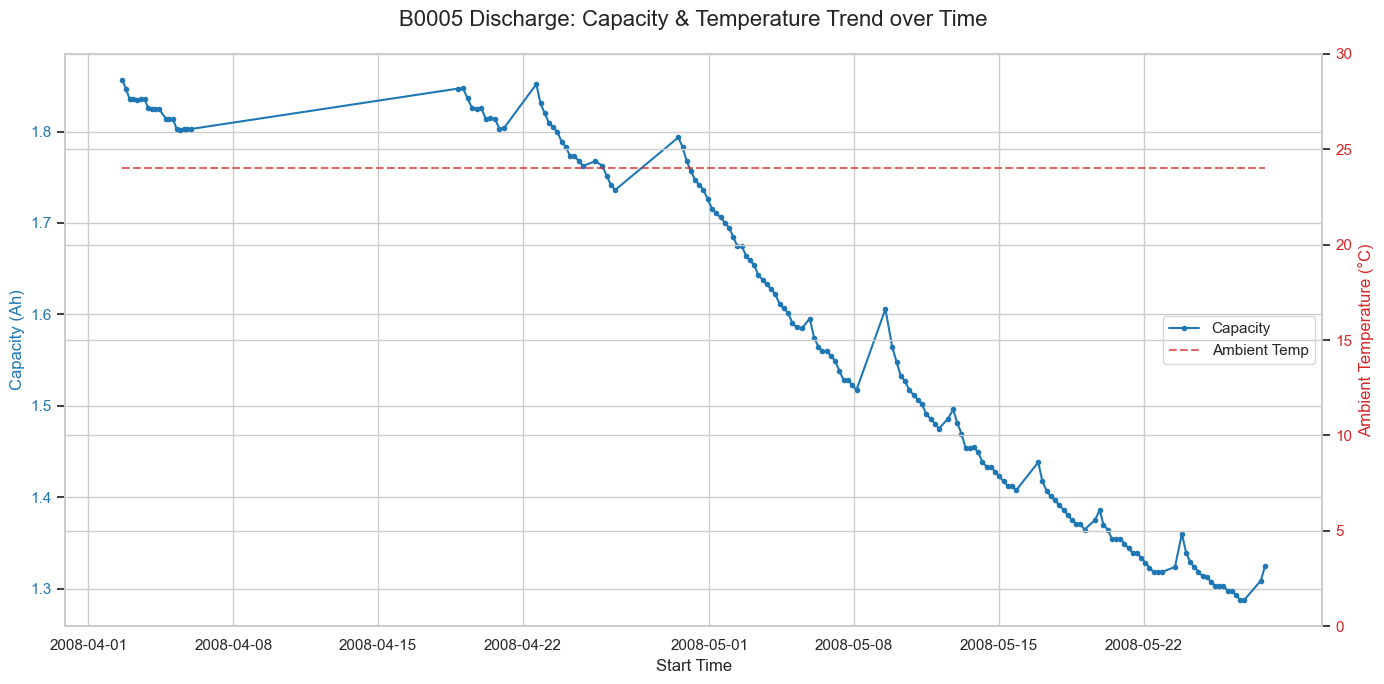

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. B0005 방전 데이터 필터링 및 시간순 정렬
b0005_discharge = df[(df['battery_id'] == 'B0005') & (df['type'] == 'discharge')].copy()
b0005_discharge['start_time'] = pd.to_datetime(b0005_discharge['start_time'])
b0005_discharge = b0005_discharge.sort_values(by='start_time').reset_index(drop=True)

# 2. 이중 축 그래프 생성
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_style("whitegrid")

# --- 왼쪽 축: Capacity (용량) ---
color_cap = 'tab:blue'
ax1.set_xlabel('Start Time', fontsize=12)
ax1.set_ylabel('Capacity (Ah)', color=color_cap, fontsize=12)
line1 = ax1.plot(b0005_discharge['start_time'], b0005_discharge['Capacity'], 
                 marker='o', markersize=3, label='Capacity', color=color_cap, linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color_cap)

# --- 오른쪽 축: Ambient Temperature (주변 온도) ---
ax2 = ax1.twinx() # x축을 공유하는 두 번째 y축 생성
color_temp = 'tab:red'
ax2.set_ylabel('Ambient Temperature (°C)', color=color_temp, fontsize=12)
line2 = ax2.plot(b0005_discharge['start_time'], b0005_discharge['ambient_temperature'], 
                 label='Ambient Temp', color=color_temp, linestyle='--', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_temp)
ax2.set_ylim(0, 30) # 온도 변화가 미세할 경우 범위를 좁혀서 확인 가능

# 3. 그래프 꾸미기
plt.title('B0005 Discharge: Capacity & Temperature Trend over Time', fontsize=16, pad=20)
fig.tight_layout()

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.xticks(rotation=45)
plt.show()

In [58]:
# 1. B0005 배터리의 'discharge' 데이터만 필터링
b0005_discharge = df[(df['battery_id'] == 'B0005') & (df['type'] == 'discharge')].copy()

# 2. start_time을 기준으로 정렬 (이미 되어 있는지 확인하기 위함)
b0005_discharge = b0005_discharge.sort_values(by='start_time')

# 3. 주요 컬럼(파일명, 시작시간, 용량) 출력
# 모든 행을 보고 싶다면 pd.set_option을 사용하세요.
pd.set_option('display.max_rows', None) # 모든 행 출력 설정

print(f"📊 [B0005] Discharge 데이터 시간순 목록 (총 {len(b0005_discharge)}개)")
print("-" * 60)
display(b0005_discharge)
print("-" * 60)

# 다시 기본 설정으로 복구 (옵션)
pd.reset_option('display.max_rows')

📊 [B0005] Discharge 데이터 시간순 목록 (총 168개)
------------------------------------------------------------


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
5121,discharge,2008-04-02 15:25:42,24,B0005,1,5122,05122.csv,1.856487,NaN,NaN
5123,discharge,2008-04-02 19:43:48,24,B0005,3,5124,05124.csv,1.846327,NaN,NaN
5125,discharge,2008-04-03 00:01:07,24,B0005,5,5126,05126.csv,1.835349,NaN,NaN
5127,discharge,2008-04-03 04:16:37,24,B0005,7,5128,05128.csv,1.835263,NaN,NaN
5129,discharge,2008-04-03 08:33:26,24,B0005,9,5130,05130.csv,1.834646,NaN,NaN
5131,discharge,2008-04-03 12:55:11,24,B0005,11,5132,05132.csv,1.835662,NaN,NaN
5133,discharge,2008-04-03 17:17:16,24,B0005,13,5134,05134.csv,1.835146,NaN,NaN
5135,discharge,2008-04-03 21:28:15,24,B0005,15,5136,05136.csv,1.825757,NaN,NaN
5137,discharge,2008-04-04 01:38:15,24,B0005,17,5138,05138.csv,1.824774,NaN,NaN
5139,discharge,2008-04-04 05:48:09,24,B0005,19,5140,05140.csv,1.824613,NaN,NaN


------------------------------------------------------------


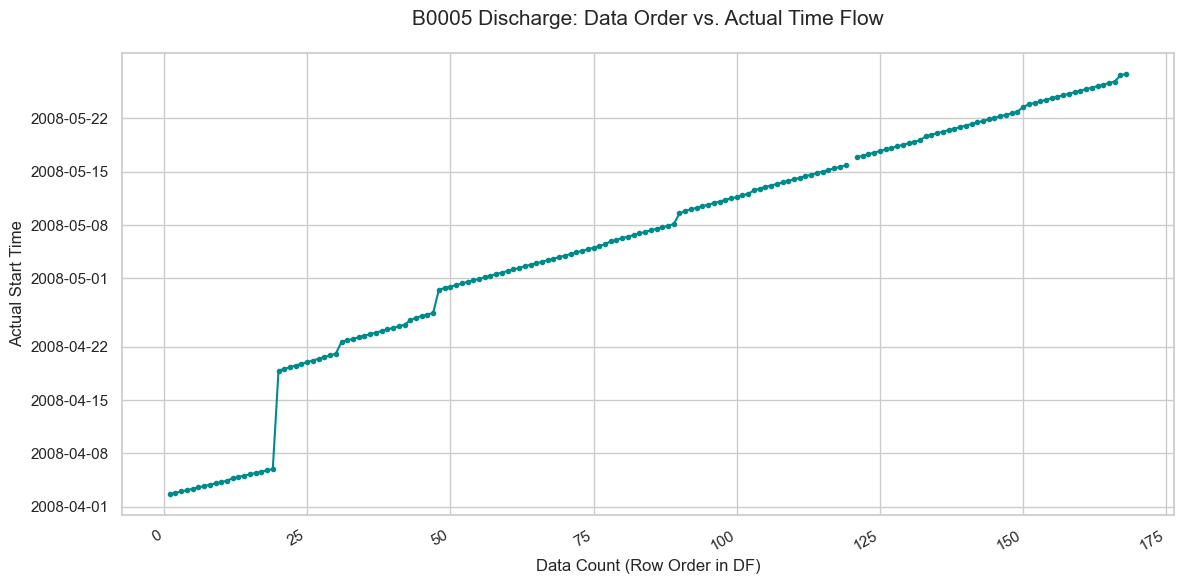

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. B0005 방전 데이터 필터링 (필터링만 하고 정렬은 하지 않은 원본 상태 유지)
b0005_discharge = df[(df['battery_id'] == 'B0005') & (df['type'] == 'discharge')].copy()

# 2. start_time을 datetime으로 변환
b0005_discharge['start_time'] = pd.to_datetime(b0005_discharge['start_time'])

# 3. 데이터가 들어있는 순서대로 인덱스 부여 (카운트)
b0005_discharge['data_count'] = range(1, len(b0005_discharge) + 1)

# 4. 시각화
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 데이터 카운트별 시간 흐름 그래프
plt.plot(b0005_discharge['data_count'], b0005_discharge['start_time'], 
         marker='o', markersize=3, linestyle='-', color='darkcyan', label='Start Time Flow')

# 그래프 꾸미기
plt.title('B0005 Discharge: Data Order vs. Actual Time Flow', fontsize=15, pad=20)
plt.xlabel('Data Count (Row Order in DF)', fontsize=12)
plt.ylabel('Actual Start Time', fontsize=12)

# y축 시간이 겹치지 않게 포맷 조정
plt.gcf().autofmt_xdate() 

plt.tight_layout()
plt.show()

In [ ]:
#### metadata 시간 전처리(1) 후 df로 저장

# 원본 CSV 불러오기
df_o = pd.read_csv("../../dataset/metadata.csv")

# start_time 전처리 함수
def parse_start_time(x):
    try:
        # 1. 대괄호 제거 및 공백 정리
        x_str = str(x).replace('[', '').replace(']', '').strip()
        
        # 2. 정규표현식으로 숫자(지수 표현 포함) 형태만 모두 추출
        # 예: '2.0080e+03', '4.0000e+00' 등을 찾아냄
        parts_raw = x_str.split()
        
        # 3. float로 먼저 변환해야 2.0080e+03 -> 2008.0 이 됩니다.
        # 그 후 int로 변환
        parts = [int(float(p)) for p in parts_raw]
        
        if len(parts) >= 5:
            # 초(parts[5])가 없을 수도 있으니 안전하게 시/분까지만 넣거나 조건부 추가
            return pd.Timestamp(year=parts[0], month=parts[1], day=parts[2],
                                hour=parts[3], minute=parts[4])
    except:
        return pd.NaT
    return pd.NaT

# start_time 컬럼 적용
df_meta['start_time'] = df_meta['start_time'].apply(parse_start_time)

# df로 저장
df = df_meta.copy()
display(df)

In [ ]:
#### 전처리 (2. Dtype 변환)
# 'Capacity', 'Re', 'Rct' 컬럼을 수치형으로 변환
cols = ['Capacity', 'Re', 'Rct']

for col in cols:
    # errors='coerce'를 사용하면 숫자로 바꿀 수 없는 문자열을 NaN으로 처리합니다.
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 확인
print(df[cols].dtypes)

In [8]:
# 변환 후 데이터 확인 (null/Dtype)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   type                 7565 non-null   object        
 1   start_time           7519 non-null   datetime64[ns]
 2   ambient_temperature  7565 non-null   int64         
 3   battery_id           7565 non-null   object        
 4   test_id              7565 non-null   int64         
 5   uid                  7565 non-null   int64         
 6   filename             7565 non-null   object        
 7   Capacity             2769 non-null   float64       
 8   Re                   1947 non-null   float64       
 9   Rct                  1947 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 591.1+ KB


In [9]:
# 결측치 확인 (1.  discharge데이터에 Capacity의 결측치 여부 확인)
# 1. Discharge 데이터만 필터링
df_dis = df[df['type'] == 'discharge']

# 2. Capacity가 NaN인 행 추출
nan_capacity = df_dis[df_dis['Capacity'].isna()]

print(f"전체 Discharge 행 수: {len(df_dis):,}개")
print(f"Capacity가 NaN인 행 수: {len(nan_capacity):,}개")

if len(nan_capacity) > 0:
    print("결측치가 발견된 배터리 및 파일 목록:")
    # 어떤 파일에서 용량이 빠졌는지 요약 출력
    display(nan_capacity[['battery_id', 'filename']].drop_duplicates())
else:
    print("\n Discharge 데이터에 Capacity 값이 정상적으로 들어있습니다.")
# 확인시 25개의 결측치가 있었지만, 해당 배터리는 대상이 아님

전체 Discharge 행 수: 2,794개
Capacity가 NaN인 행 수: 25개
결측치가 발견된 배터리 및 파일 목록:


,battery_id,filename
4370,B0050,04371.csv
4372,B0050,04373.csv
4374,B0050,04375.csv
4376,B0050,04377.csv
4390,B0052,04391.csv
4394,B0052,04395.csv
4396,B0052,04397.csv
4398,B0052,04399.csv
4400,B0052,04401.csv
4402,B0052,04403.csv


In [10]:
# 결측치 확인 (2. impedance 데이터에 Re, RCT의 결측치 여부 확인)
# 1. Impedance 데이터만 필터링
df_imp = df[df['type'] == 'impedance']

# 2. Re 또는 Rct가 NaN인 행 추출
nan_imp = df_imp[df_imp['Re'].isna() | df_imp['Rct'].isna()]

print(f"전체 Impedance 행 수: {len(df_imp):,}개")
print(f"Re/Rct 결측 행 수: {len(nan_imp):,}개")

if len(nan_imp) > 0:
    print("\n결측치가 발견된 배터리 및 파일 목록 (상위 10개):")
    # 중복을 제거하고 파일 단위로 요약
    summary = nan_imp.groupby(['battery_id', 'filename']).size().reset_index(name='missing_rows')
    display(summary.head(10))
else:
    print("\n Impedance 데이터에 Re, Rct 값이 채워져 있습니다.")

# 3. (참고) 값의 범위 확인 (0이나 음수가 있는지 체크)
if len(df_imp) > len(nan_imp):
    print("\n--- [Re, Rct 값의 범위 요약] ---")
    display(df_imp[['Re', 'Rct']].describe())

# 결측이 있었으나, 해당 배터리는 대상이 아님

전체 Impedance 행 수: 1,956개
Re/Rct 결측 행 수: 9개

결측치가 발견된 배터리 및 파일 목록 (상위 10개):


,battery_id,filename,missing_rows
0,B0049,04268.csv,1
1,B0049,04280.csv,1
2,B0049,04282.csv,1
3,B0049,04292.csv,1
4,B0049,04294.csv,1
5,B0049,04306.csv,1
6,B0049,04316.csv,1
7,B0049,04318.csv,1
8,B0051,04454.csv,1



--- [Re, Rct 값의 범위 요약] ---


,Re,Rct
count,1.947000e+03,1.947000e+03
mean,-4.976500e+11,1.055903e+12
std,2.195872e+13,4.659154e+13
min,-9.689245e+14,-2.091081e+02
25%,5.782157e-02,8.155754e-02
50%,7.255344e-02,1.014191e-01
75%,9.229960e-02,1.565123e-01
max,4.482291e+02,2.055843e+15


In [22]:
# 데이터 시간 범위 확인
# 1. 전체 시간 범위 확인 (Min, Max)
start_date = df['start_time'].min()
end_date = df['start_time'].max()
duration = end_date - start_date

print("=== [데이터셋 시간 범위 결과] ===")
print(f"전체 시작 시점: {start_date}")
print(f"전체 종료 시점: {end_date}")
print(f"총 실험 기간  : {duration.days}일 {duration.seconds // 3600}시간")

# 2. 배터리별 시간 범위 확인 (각 배터리마다 실험 시점이 다를 수 있음)
print("\n=== [배터리 ID별 시간 범위] ===")
battery_time_range = df.groupby('battery_id')['start_time'].agg(['min', 'max', 'count', 'nunique'])
battery_time_range.columns = ['시작 시간', '종료 시간', '행 수', '파일 수']
display(battery_time_range)

# 전체 2008-04-02~2010-09-30 데이터였고,
# 해당 배터리는 2008-04-02~2008-05-28 (616사이클) & 07-07~08-20 (319사이클)이었음

=== [데이터셋 시간 범위 결과] ===
전체 시작 시점: 2008-04-02 13:08:18
전체 종료 시점: 2010-09-30 15:32:33
총 실험 기간  : 911일 2시간

=== [배터리 ID별 시간 범위] ===


,시작 시간,종료 시간,행 수,파일 수
battery_id,,,,
B0005,2008-04-02 13:08:18,2008-05-28 11:09:42,610,610
B0006,2008-04-02 13:08:18,2008-05-28 11:09:42,610,610
B0007,2008-04-02 13:08:18,2008-05-28 11:09:42,610,610
B0018,2008-07-07 12:26:46,2008-08-20 08:37:20,316,316
B0025,2009-02-13 19:03:52,2009-03-19 12:55:27,79,79
B0026,2009-02-13 19:03:52,2009-03-19 12:55:27,79,79
B0027,2009-02-13 19:03:52,2009-03-19 12:55:27,79,79
B0028,2009-02-13 19:03:52,2009-03-19 12:55:27,79,79
B0029,2009-04-07 15:59:19,2009-04-18 01:29:13,96,96


In [23]:
print(df.columns)

Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct'], dtype='object')


In [ ]:
# 'B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data 구성하기

# 대상 배터리 ID 리스트
target_battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

# 데이터 저장할 폴더 경로
data_folder = "../../dataset/data"

# 데이터를 쌓아두기 위한 저장소(Dictionary) 생성
collected_data = {}


### 각 배터리별 EOL 사이클 번호를 먼저 파악 (RUL 계산용)
# SOH 80% 기준을 찾기 위해 메타데이터(df)에서 미리 계산
eol_dict = {}
for b_id in target_battery_ids:
    b_meta = df[(df['battery_id'] == b_id) & (df['type'] == 'discharge')].copy()
    if not b_meta.empty:
        initial_cap = b_meta['Capacity'].iloc[0] # 첫 번째 방전 용량
        # SOH 80% 이하인 첫 번째 행의 인덱스(순번) 찾기
        eol_idx = np.where((b_meta['Capacity'] / initial_cap) * 100 <= 80)[0]
        eol_dict[b_id] = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan



for battery_id in target_battery_ids:
    # 해당 배터리 데이터만 필터링 (시간순 정렬 권장)
    filtered_df = df[df['battery_id'] == battery_id].sort_values('start_time')

    # [핵심] 각 배터리 내에서 타입별(충전/방전/임피던스)로 사이클 번호를 관리하기 위한 카운터
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    
    ### cycle로 명칭 변경 및 초기 용량 설정
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    ### 해당 배터리의 첫 번째 방전 용량을 분모로 저장
    first_discharge_row = filtered_df[filtered_df['type'] == 'discharge']
    first_cap = first_discharge_row['Capacity'].iloc[0] if not first_discharge_row.empty else None


    for _, row in filtered_df.iterrows():
        filename = row['filename']
        file_path = os.path.join(data_folder, filename)

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)
            #temp_df['filename'] = filename

            # 현재 행의 타입 확인
            data_type = row['type']

            # 정보 결합
            temp_df['type'] = row['type']
            temp_df['start_time'] = row['start_time']
            temp_df['ambient_temperature'] = row['ambient_temperature']
            temp_df['battery_id'] = row['battery_id']
            temp_df['cycle_index'] = cycle_counters[data_type]

            # 다음 파일을 위해 해당 타입의 카운터 1 증가
            cycle_counters[data_type] += 1

            if row['type'] == 'discharge':
                temp_df['Capacity'] = row['Capacity']
            elif row['type'] == 'impedance':
                temp_df['Re'] = row['Re']
                temp_df['Rct'] = row['Rct']

            # 데이터를 리스트에 추가
            key = f"df_{row['type']}_{battery_id}"
            if key not in collected_data:
                collected_data[key] = []
            collected_data[key].append(temp_df)

# 리스트에 모인 데이터들을 하나로 합치기
for key, df_list in collected_data.items():
    # len(df_list)가 바로 합친 파일(데이터프레임)의 개수입니다.
    file_count = len(df_list) 
    
    globals()[key] = pd.concat(df_list, ignore_index=True)
    
    # 출력 문구에 파일 개수 정보를 추가했습니다.
    print(f"{key} 생성 완료: {file_count}개의 파일 통합됨 | 전체 크기: {globals()[key].shape}")

df_charge_B0005 생성 완료: 170개의 파일 통합됨 | 전체 크기: (541173, 12)
df_discharge_B0005 생성 완료: 168개의 파일 통합됨 | 전체 크기: (50285, 13)
df_impedance_B0005 생성 완료: 278개의 파일 통합됨 | 전체 크기: (13344, 13)
df_charge_B0006 생성 완료: 170개의 파일 통합됨 | 전체 크기: (541173, 12)
df_discharge_B0006 생성 완료: 168개의 파일 통합됨 | 전체 크기: (50285, 13)
df_impedance_B0006 생성 완료: 278개의 파일 통합됨 | 전체 크기: (13344, 13)
df_charge_B0007 생성 완료: 170개의 파일 통합됨 | 전체 크기: (541173, 12)
df_discharge_B0007 생성 완료: 168개의 파일 통합됨 | 전체 크기: (50285, 13)
df_impedance_B0007 생성 완료: 278개의 파일 통합됨 | 전체 크기: (13344, 13)
df_charge_B0018 생성 완료: 134개의 파일 통합됨 | 전체 크기: (279810, 12)
df_impedance_B0018 생성 완료: 53개의 파일 통합됨 | 전체 크기: (2544, 13)
df_discharge_B0018 생성 완료: 132개의 파일 통합됨 | 전체 크기: (34866, 13)


In [25]:
# 간단 확인
display(df_charge_B0006)
display(df_discharge_B0007)
display(df_impedance_B0005) 

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,filename,type,start_time,ambient_temperature,battery_id,cycle_index
0,3.864624,0.000082,24.682214,-0.001,-0.007,0.000,04505.csv,charge,2008-04-02 13:08:18,24,B0006,1
1,3.469113,-4.059185,24.695407,-4.060,1.558,2.532,04505.csv,charge,2008-04-02 13:08:18,24,B0006,1
2,3.994806,1.513750,24.711491,1.506,4.710,5.500,04505.csv,charge,2008-04-02 13:08:18,24,B0006,1
3,4.005888,1.511389,24.739672,1.506,4.726,8.344,04505.csv,charge,2008-04-02 13:08:18,24,B0006,1
4,4.012944,1.510817,24.753180,1.506,4.737,11.125,04505.csv,charge,2008-04-02 13:08:18,24,B0006,1
...,...,...,...,...,...,...,...,...,...,...,...,...
541168,4.195731,0.033067,24.872578,0.035,4.224,10200.812,05117.csv,charge,NaT,24,B0006,170
541169,4.196132,0.032702,24.869662,0.035,4.224,10203.687,05117.csv,charge,NaT,24,B0006,170
541170,4.196657,0.044100,24.860848,0.035,4.224,10206.578,05117.csv,charge,NaT,24,B0006,170
541171,4.196401,0.034460,24.868679,0.035,4.224,10209.406,05117.csv,charge,NaT,24,B0006,170


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,filename,type,start_time,ambient_temperature,battery_id,cycle_index,Capacity
0,4.199360,-0.001866,23.937044,-0.0004,0.000,0.000,05738.csv,discharge,2008-04-02 15:25:42,24,B0007,1,1.891052
1,4.199497,-0.002139,23.924074,-0.0004,4.215,16.781,05738.csv,discharge,2008-04-02 15:25:42,24,B0007,1,1.891052
2,3.985606,-1.988778,24.004257,-2.0000,3.003,35.703,05738.csv,discharge,2008-04-02 15:25:42,24,B0007,1,1.891052
3,3.963247,-1.992558,24.162868,-2.0000,2.987,53.781,05738.csv,discharge,2008-04-02 15:25:42,24,B0007,1,1.891052
4,3.946647,-1.988491,24.346368,-2.0000,2.972,71.922,05738.csv,discharge,2008-04-02 15:25:42,24,B0007,1,1.891052
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50280,3.185954,-0.000325,40.951107,0.0006,0.001,2906.953,06167.csv,discharge,NaT,24,B0007,168,1.533960
50281,3.212955,-0.003110,40.802700,0.0006,0.001,2916.688,06167.csv,discharge,NaT,24,B0007,168,1.533960
50282,3.236405,-0.004553,40.622755,0.0006,0.001,2926.453,06167.csv,discharge,NaT,24,B0007,168,1.533960
50283,3.256967,-0.005301,40.451520,0.0006,0.001,2936.235,06167.csv,discharge,NaT,24,B0007,168,1.533960


,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,filename,type,start_time,ambient_temperature,battery_id,cycle_index,Re,Rct
0,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j),05161.csv,impedance,2008-04-18 20:55:30,24,B0005,1,0.044669,0.069456
1,(820.6094970703125-36.23455047607422j),(337.0914611816406-82.9207763671875j),(2.3204145178633437+0.4633045948164565j),(0.13008840651776496-0.19711481029612374j),(0.06817886114940203-0.001190040925296937j),05161.csv,impedance,2008-04-18 20:55:30,24,B0005,1,0.044669,0.069456
2,(827.2421875-48.23122787475586j),(330.6315612792969-70.01371765136719j),(2.424192647592199+0.36746495469515333j),(0.058770560504133235+0.03330656583655633j),(0.06793257733714593-5.6826811936507056e-05j),05161.csv,impedance,2008-04-18 20:55:30,24,B0005,1,0.044669,0.069456
3,(827.1934814453125-56.195716857910156j),(330.8086242675781-61.73442459106445j),(2.4470021712116985+0.28677775364826635j),(0.0058135116366746726-0.060546548141956195j),(0.06691839226387165-0.0008787264015490232j),05161.csv,impedance,2008-04-18 20:55:30,24,B0005,1,0.044669,0.069456
4,(824.9295043945312-53.241477966308594j),(332.68267822265625-57.62901306152344j),(2.434304977711638+0.2616460702282485j),(0.12608106668700975-0.09044390544679616j),(0.06807105294348659-0.0001974802021297548j),05161.csv,impedance,2008-04-18 20:55:30,24,B0005,1,0.044669,0.069456
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13339,(919.2137451171875-61.344268798828125j),(225.83346557617188+91.30834197998047j),(3.404025967481483-1.6479410391939207j),(0.2523114357189438-0.05158848510411978j),NaN,05618.csv,impedance,NaT,24,B0005,278,0.055996,0.076514
13340,(920.7554931640625+2.2879276275634766j),(208.63681030273438+110.14028930664062j),(3.4558890457178855-1.813412940556713j),(0.2718823353789192-0.05689254121837037j),NaN,05618.csv,impedance,NaT,24,B0005,278,0.055996,0.076514
13341,(918.208251953125+125.94090270996094j),(173.1456298828125+129.90370178222656j),(3.7423167760778653-2.0803291425147155j),(0.295899312558445-0.06023857713795717j),NaN,05618.csv,impedance,NaT,24,B0005,278,0.055996,0.076514
13342,(881.9716186523438+291.8736877441406j),(134.8563995361328+144.38916015625j),(4.126682912354244-2.2540613070452835j),(0.32512471789259745-0.06004882348416756j),NaN,05618.csv,impedance,NaT,24,B0005,278,0.055996,0.076514


In [ ]:
# 분석가 팁: 반복되는 작업을 줄이기 위해 리스트를 순회하며 출력합니다.

# 1. 방전(Discharge) 데이터 확인
print("=== [DISCHARGE DATA SHAPE & PREVIEW] ===")
discharge_dfs = [df_discharge_B0005, df_discharge_B0006, df_discharge_B0007, df_discharge_B0018]
df_names_dis = ['B0005', 'B0006', 'B0007', 'B0018']

for name, df_obj in zip(df_names_dis, discharge_dfs):
    print(f"Discharge_{name} Shape: {df_obj.shape}")
    display(df_obj.head())  # 전체 출력 대신 head()를 권장하지만, 원하시면 그대로 사용 가능합니다.
    print("-" * 50)

# 2. 임피던스(Impedance) 데이터 확인
print("\n=== [IMPEDANCE DATA SHAPE & PREVIEW] ===")
impedance_dfs = [df_impedance_B0005, df_impedance_B0006, df_impedance_B0007, df_impedance_B0018]
df_names_imp = ['B0005', 'B0006', 'B0007', 'B0018']

for name, df_obj in zip(df_names_imp, impedance_dfs):
    print(f"Impedance_{name} Shape: {df_obj.shape}")
    display(df_obj.head())
    print("-" * 50)

# 3. 충전(Charge) 데이터 확인
print("\n=== [CHARGE DATA SHAPE & PREVIEW] ===")
charge_dfs = [df_charge_B0005, df_charge_B0006, df_charge_B0007, df_charge_B0018]
df_names_cha = ['B0005', 'B0006', 'B0007', 'B0018']

for name, df_obj in zip(df_names_cha, charge_dfs):
    print(f"Charge_{name} Shape: {df_obj.shape}")
    display(df_obj.head())
    print("-" * 50)

# 분석

# discharge 분석

배터리 4개를 모두 합침

각 배터리의 초기의 첫Ah과 최종의 첫Ah를 확인 (떨어짐 확인)

Capacity 값을 그래프로 확인

각 배터리의 1cycle의 Ah값을 시간으로 적분한 값과 capacity를 비교 (거의 같음)

In [26]:
# 1. 4개 배터리 데이터를 하나로 통합 (df_battery_discharge)

battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
all_dfs = []

for b_id in battery_ids:
    df_name = f"df_discharge_{b_id}"
    if df_name in globals():
        # .copy()를 써서 원본 데이터와 연결을 끊고 독립적인 복사본을 만들기
        temp_df = globals()[df_name].copy()
        temp_df['battery_id'] = b_id  # 배터리 식별자 추가
        all_dfs.append(temp_df)

# 통합 데이터프레임 생성
df_battery_discharge = pd.concat(all_dfs, ignore_index=True)

print(f"✅ 통합 완료! 전체 행 개수: {len(df_battery_discharge)}")
print(f"체크 - 포함된 배터리들: {df_battery_discharge['battery_id'].unique()}")

✅ 통합 완료! 전체 행 개수: 185721
체크 - 포함된 배터리들: ['B0005' 'B0006' 'B0007' 'B0018']


In [27]:
# 배터리별 초기/끝 Capacity 값 

# 1. 배터리별 첫 번째(초기)와 마지막(최종) 사이클의 용량 정보 추출
# groupby와 agg를 사용하여 필요한 값만 한 번에 가져옵니다.
summary_df = df_battery_discharge.groupby('battery_id').agg(
    Initial_Capacity=('Capacity', 'first'),
    Final_Capacity=('Capacity', 'last'),
    Total_Cycles=('cycle_index', 'max')
).reset_index()

# 2. 감소율(Degradation Rate) 계산
summary_df['Degradation_Rate (%)'] = (
    (summary_df['Initial_Capacity'] - summary_df['Final_Capacity']) / 
    summary_df['Initial_Capacity'] * 100
).round(2)

# 3. 소수점 정리 및 결과 출력
summary_df['Initial_Capacity'] = summary_df['Initial_Capacity'].round(4)
summary_df['Final_Capacity'] = summary_df['Final_Capacity'].round(4)

display(summary_df)

,battery_id,Initial_Capacity,Final_Capacity,Total_Cycles,Degradation_Rate (%)
0,B0005,1.8565,1.4334,168,22.79
1,B0006,2.0353,1.3842,168,31.99
2,B0007,1.8911,1.5340,168,18.88
3,B0018,1.8550,1.4284,132,23.00


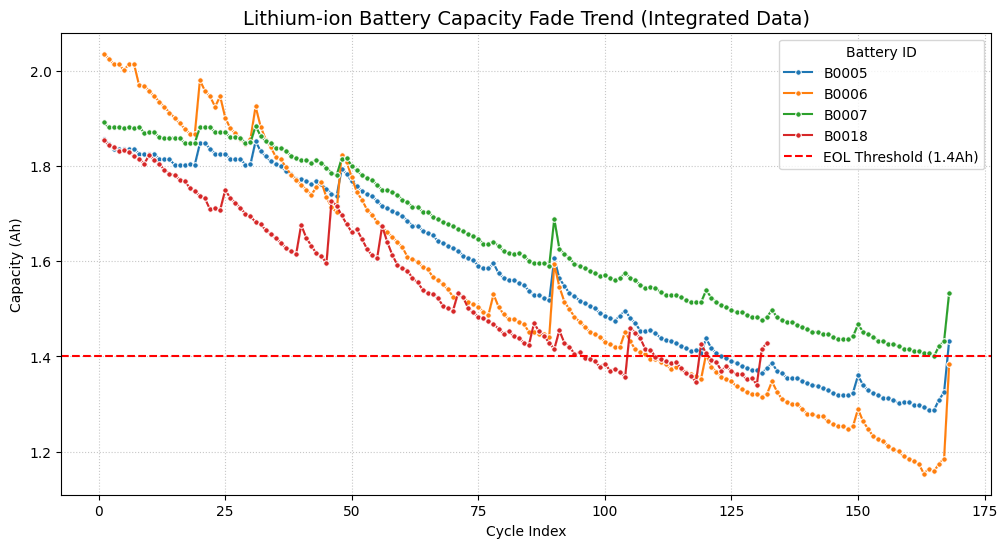

In [28]:
# Capacity 시각화
plt.figure(figsize=(12, 6))

# Seaborn을 사용하면 통합 데이터프레임에서 hue 옵션 하나로 간단히 구분 가능합니다.
sns.lineplot(data=df_battery_discharge, x='cycle_index', y='Capacity', hue='battery_id', marker='o', markersize=4)

# 수명 종료 선 (EOL: End of Life) 설정
plt.axhline(y=1.4, color='red', linestyle='--', label='EOL Threshold (1.4Ah)')

plt.title('Lithium-ion Battery Capacity Fade Trend (Integrated Data)', fontsize=14)
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.legend(title='Battery ID')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 3. (선택사항) 통합 데이터 CSV 저장
# df_battery_discharge.to_csv("df_battery_discharge.csv", index=False)

In [29]:
# discharge 배터리별 전류적분값과 capacity값을 비교

def calculate_metrics(group):
    # 각 그룹 내에서 시간 차이 계산
    # 'Time' 컬럼이 있는 통합 데이터라면 바로 작동합니다.
    dt = group['Time'].diff().fillna(0)
    
    # 전류 적분 (Ah) 계산
    integrated_ah = (group['Current_measured'].abs() * dt).sum() / 3600
    
    # 해당 사이클의 Capacity 값 (첫 행)
    provided_cap = group['Capacity'].iloc[0]
    
    return pd.Series({
        'Integrated_Ah': integrated_ah,
        'Provided_Capacity': provided_cap
    })

# 배터리 ID와 사이클 인덱스로 그룹화하여 결과 도출
# (이미 배터리 ID가 컬럼으로 들어있다고 가정합니다)
final_comparison_df = (
    df_battery_discharge
    .groupby(['battery_id', 'cycle_index'])
    .apply(calculate_metrics)
    .reset_index()
)

# 오차율 계산
final_comparison_df['Error_Rate(%)'] = (
    abs(final_comparison_df['Integrated_Ah'] - final_comparison_df['Provided_Capacity']) 
    / final_comparison_df['Provided_Capacity'] * 100
)

display(final_comparison_df)

C:\Users\skrke\AppData\Local\Temp\ipykernel_14680\2832342442.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_metrics)


,battery_id,cycle_index,Integrated_Ah,Provided_Capacity,Error_Rate(%)
0,B0005,1,1.861952,1.856487,0.294348
1,B0005,2,1.851834,1.846327,0.298256
2,B0005,3,1.840799,1.835349,0.296920
3,B0005,4,1.840688,1.835263,0.295651
4,B0005,5,1.840087,1.834646,0.296588
...,...,...,...,...,...
631,B0018,128,1.363689,1.351865,0.874664
632,B0018,129,1.374382,1.354797,1.445642
633,B0018,130,1.360682,1.341051,1.463803
634,B0018,131,1.433741,1.415561,1.284350


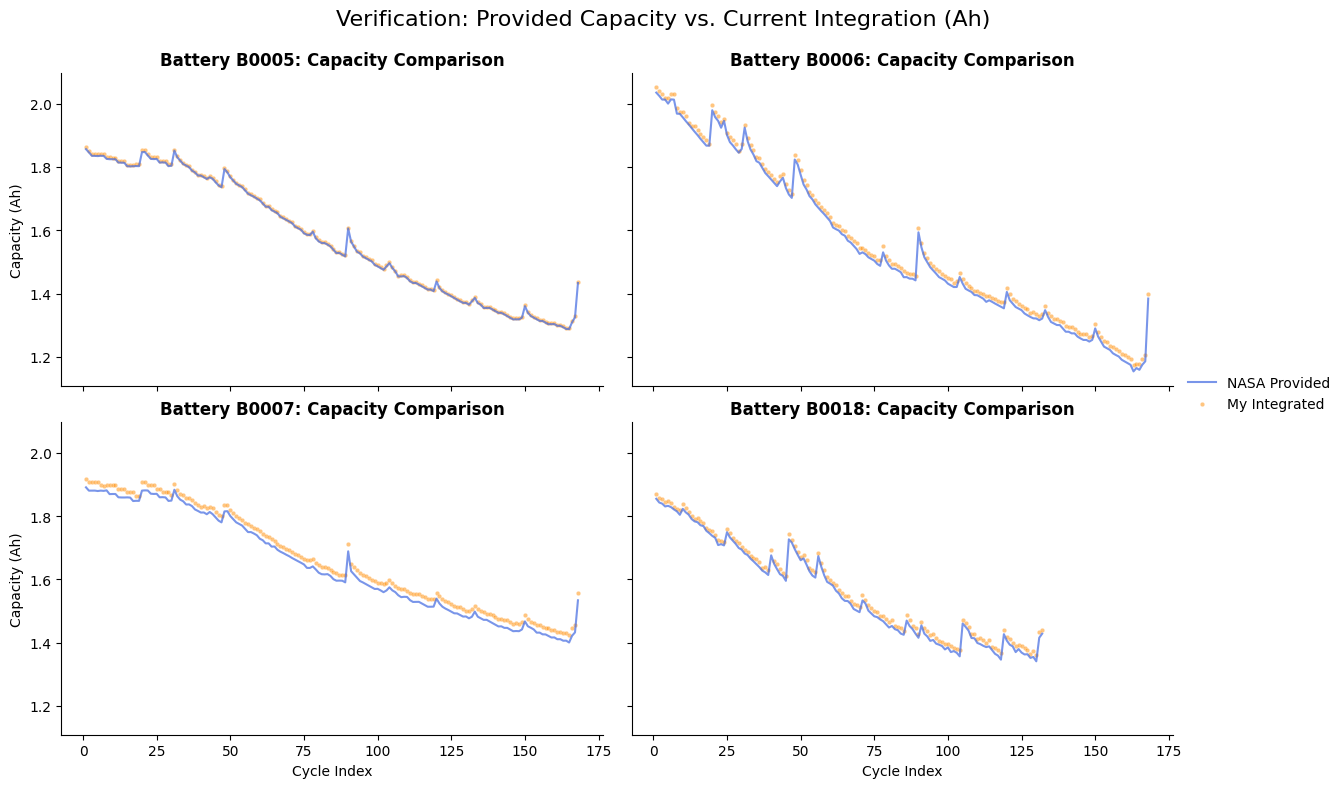

In [30]:
# 사이클별 전류적분값과 capacity값 시각화

# Seaborn의 FacetGrid를 사용하면 배터리별 격자(2x2)를 자동으로 생성
g = sns.FacetGrid(final_comparison_df, col="battery_id", col_wrap=2, height=4, aspect=1.5)

# 1. NASA 제공 capacity 값 (실선)
g.map(sns.lineplot, "cycle_index", "Provided_Capacity", color='royalblue', label='NASA Provided', alpha=0.7)

# 2. 직접 적분한 값 (산점도)
g.map(sns.scatterplot, "cycle_index", "Integrated_Ah", color='darkorange', label='My Integrated', s=10, alpha=0.5)

# 3. 디자인 디테일 설정
g.set_axis_labels("Cycle Index", "Capacity (Ah)")
g.add_legend()
g.set_titles("Battery {col_name}: Capacity Comparison", size=12, weight='bold')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Verification: Provided Capacity vs. Current Integration (Ah)', fontsize=16)
plt.show()

In [ ]:
# 더 볼것없을까...?...방전에 있는 컬럼이 이건데.. 
# 'Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'type', 'start_time', 
# 'ambient_temperature', 'battery_id', 'cycle_index', 'Capacity' 
# 이중에서 일단 Current_measured, capacity 이거를 사용했어 이제 뭘 봐야할까?
# 1. 전압강하 특성 분석, 2. 온도변화와 용량의 상관관계, 3. 방전 부하의 안정성 확인

In [31]:
# 각 배터리별 방전 데이터의 'Time' 평균값을 비교 (완전히 똑같으면 복제된 데이터임)
for b_id in ['B0005', 'B0006', 'B0007', 'B0018']:
    df_name = f"df_discharge_{b_id}"
    if df_name in globals():
        mean_time = globals()[df_name]['Time'].mean()
        max_time = globals()[df_name]['Time'].max()
        min_time = globals()[df_name]['Time'].min()
        print(f"[{b_id}] Time 평균: {mean_time:.6f} | 최대값: {max_time:.6f} | 최솟값: {min_time:.6f}")

[B0005] Time 평균: 1546.208924 | 최대값: 3690.234000 | 최솟값: 0.000000
[B0006] Time 평균: 1546.208924 | 최대값: 3690.234000 | 최솟값: 0.000000
[B0007] Time 평균: 1546.208924 | 최대값: 3690.234000 | 최솟값: 0.000000
[B0018] Time 평균: 1547.119848 | 최대값: 3434.891000 | 최솟값: 0.000000


In [32]:
# 부하가 일정했는지 확인해보는 코드
print(df_battery_discharge[['Current_load', 'Voltage_load','ambient_temperature']].nunique())
print("\n")
print(df_battery_discharge[['Current_load', 'Voltage_load']].describe())
# 2A정도로 통제 / 전압값은 4.249부터 0까지 떨어졌나봄

Current_load             21
Voltage_load           1835
ambient_temperature       1
dtype: int64


        Current_load   Voltage_load
count  185721.000000  185721.000000
mean        1.465434       2.366494
std         1.226874       0.751377
min        -2.000000       0.000000
25%         1.998200       2.410000
50%         1.998800       2.558000
75%         1.999000       2.718000
max         2.000000       4.249000


In [33]:
# 각 배터리가 참조하는 파일 이름들이 정말 고유한지 확인
for b_id in ['B0005', 'B0006', 'B0007', 'B0018']:
    unique_files = df[df['battery_id'] == b_id]['filename'].nunique()
    first_file = df[df['battery_id'] == b_id]['filename'].iloc[0] if unique_files > 0 else "None"
    print(f"배터리 {b_id}: 고유 파일 개수 = {unique_files}개 / 첫 번째 파일명 = {first_file}")

배터리 B0005: 고유 파일 개수 = 616개 / 첫 번째 파일명 = 05121.csv
배터리 B0006: 고유 파일 개수 = 616개 / 첫 번째 파일명 = 04505.csv
배터리 B0007: 고유 파일 개수 = 616개 / 첫 번째 파일명 = 05737.csv
배터리 B0018: 고유 파일 개수 = 319개 / 첫 번째 파일명 = 06353.csv


In [34]:
# 각 배터리가 참조하는 파일 이름들이 정말 고유한지 확인
for b_id in ['B0005', 'B0006', 'B0007', 'B0018']:
    unique_files = df[df['battery_id'] == b_id]['filename'].nunique()
    first_file = df[df['battery_id'] == b_id]['filename'].iloc[1] if unique_files > 0 else "None"
    print(f"배터리 {b_id}: 고유 파일 개수 = {unique_files}개 / 첫 번째 파일명 = {first_file}")

배터리 B0005: 고유 파일 개수 = 616개 / 첫 번째 파일명 = 05122.csv
배터리 B0006: 고유 파일 개수 = 616개 / 첫 번째 파일명 = 04506.csv
배터리 B0007: 고유 파일 개수 = 616개 / 첫 번째 파일명 = 05738.csv
배터리 B0018: 고유 파일 개수 = 319개 / 첫 번째 파일명 = 06354.csv


In [35]:
# 각 배터리별 첫 번째 사이클의 Duration 값을 출력
for b_id in ['B0005', 'B0006', 'B0007', 'B0018']:
    val = df_plot[(df_plot['battery_id'] == b_id) & (df_plot['cycle_index'] == 1)]['Duration'].values
    print(f"{b_id}의 1번 사이클 Duration: {val}")

NameError: name 'df_plot' is not defined

NameError: name 'df_plot' is not defined

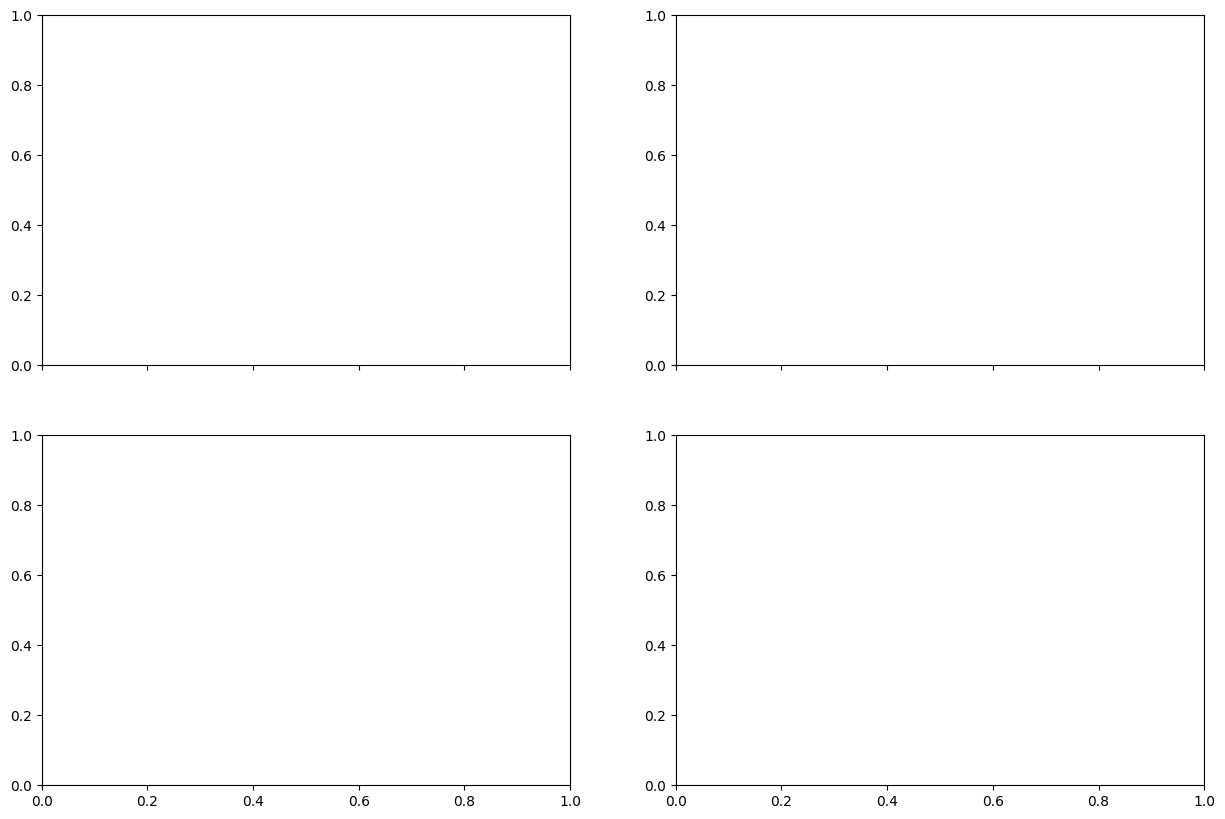

In [36]:

# 1. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()
target_ids = ['B0005', 'B0006', 'B0007', 'B0018']

for i, b_id in enumerate(target_ids):
    # 해당 배터리 데이터만 딱 집어내기
    target_data = df_plot[df_plot['battery_id'] == b_id]
    
    # 만약 데이터가 비어있다면 출력
    if target_data.empty:
        axes[i].text(0.5, 0.5, f'No Data for {b_id}', ha='center')
        continue
        
    sns.lineplot(data=target_data, x='cycle_index', y='Duration', ax=axes[i], color='red')
    axes[i].set_title(f'Battery {b_id} Discharge Duration')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

배터리별 계산된 방전 시간(Duration) 통계:
                 min       max         mean         std
battery_id                                             
B0005       2792.485  3690.234  3129.523887  246.654499
B0006       2792.485  3690.234  3129.523887  246.654499
B0007       2792.485  3690.234  3129.523887  246.654499
B0018       2742.843  3434.891  3069.074083  220.797987


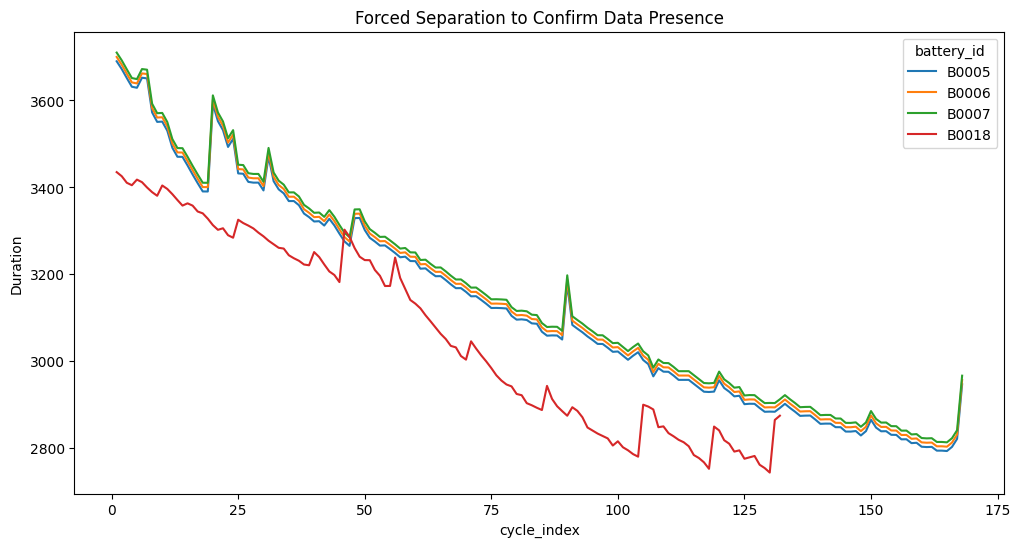

In [37]:
# 계산된 방전 시간의 요약 통계 확인

# 1. df_plot 정의 (에러 해결 핵심 구간)
# 배터리ID와 사이클별로 Time의 최대값에서 최소값을 빼서 '방전 지속 시간'을 구합니다.
df_plot = df_battery_discharge.groupby(['battery_id', 'cycle_index'])['Time'].agg(lambda x: x.max() - x.min()).reset_index()
df_plot.columns = ['battery_id', 'cycle_index', 'Duration']

# 2. 통계 확인 
print("배터리별 계산된 방전 시간(Duration) 통계:")
summary = df_plot.groupby('battery_id')['Duration'].agg(['min', 'max', 'mean', 'std'])
print(summary)

# 시각화를 위해 억지로 1초씩 차이를 둬서 선이 3개인지 확인만 해보는 코드
plt.figure(figsize=(12, 6))
df_plot_offset = df_plot.copy()
df_plot_offset.loc[df_plot_offset['battery_id']=='B0006', 'Duration'] += 10 
df_plot_offset.loc[df_plot_offset['battery_id']=='B0007', 'Duration'] += 20

sns.lineplot(data=df_plot_offset, x='cycle_index', y='Duration', hue='battery_id')
plt.title("Forced Separation to Confirm Data Presence")
plt.show()

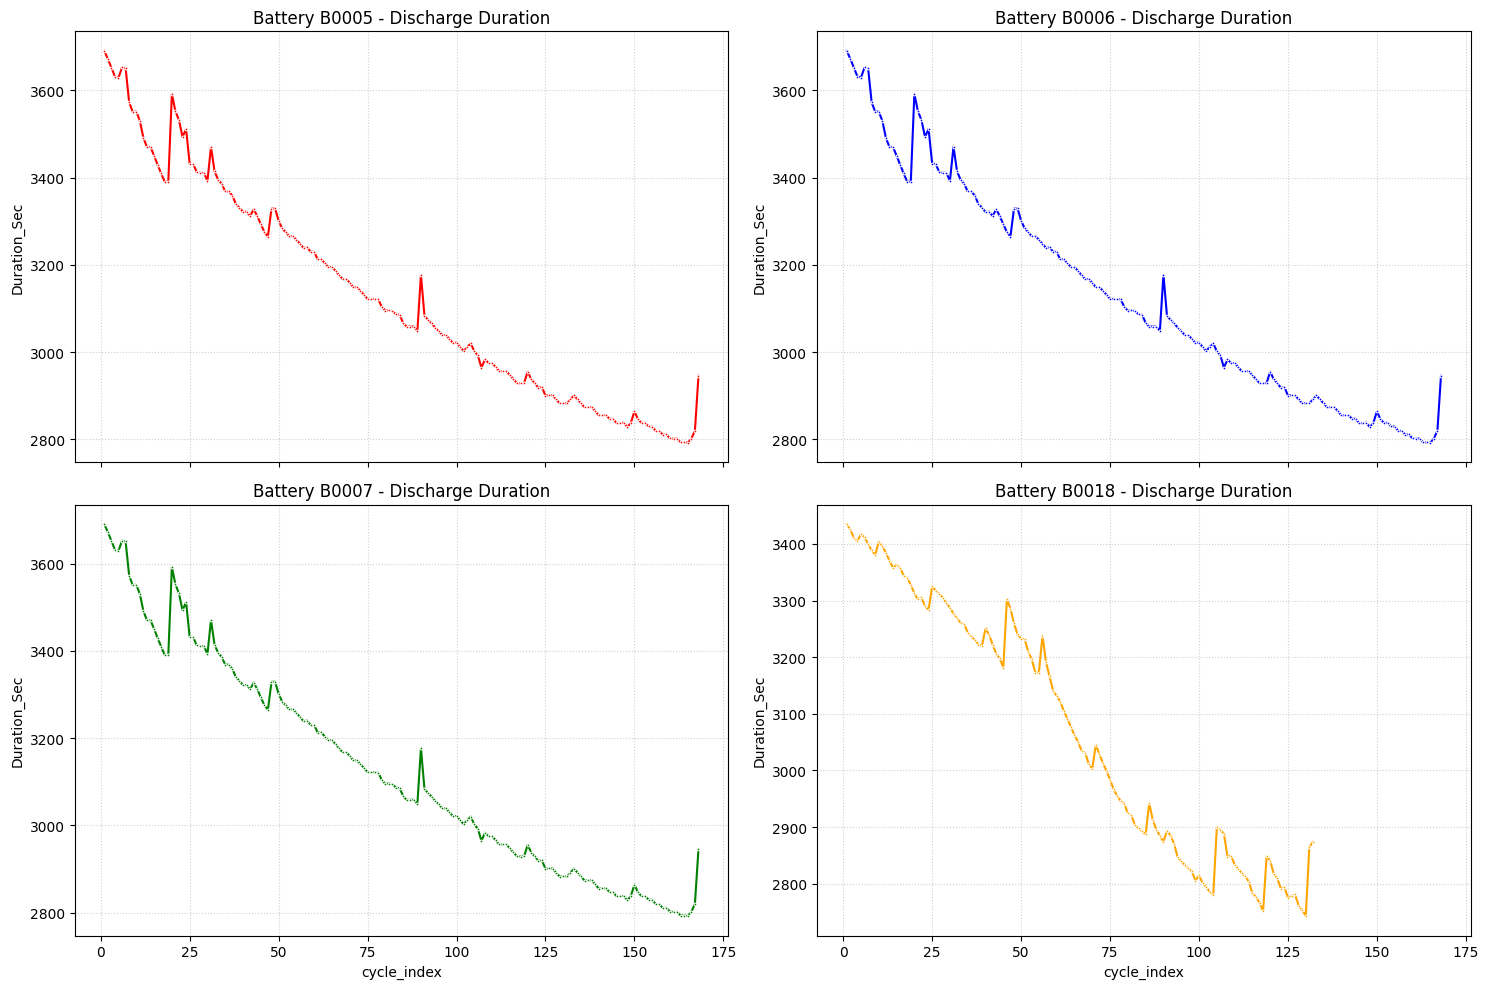

각 배터리별 사이클 데이터 개수:
battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: count, dtype: int64


In [38]:


# 1. 방전 시간 계산 (최대 - 최소 시간)
discharge_duration = (
    df_battery_discharge
    .groupby(['battery_id', 'cycle_index'])['Time']
    .agg(lambda x: x.max() - x.min())
    .reset_index()
)
discharge_duration.columns = ['battery_id', 'cycle_index', 'Duration_Sec']

# 2. 4분할 그래프 그리기 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # 2D 배열을 1D로 펴서 반복문 돌리기 편하게 함
target_ids = ['B0005', 'B0006', 'B0007', 'B0018']
colors = ['red', 'blue', 'green', 'orange']

for i, b_id in enumerate(target_ids):
    # 해당 배터리 데이터만 필터링
    data = discharge_duration[discharge_duration['battery_id'] == b_id]
    
    if not data.empty:
        sns.lineplot(data=data, x='cycle_index', y='Duration_Sec', 
                     ax=axes[i], color=colors[i], marker='o', markersize=2)
        axes[i].set_title(f'Battery {b_id} - Discharge Duration', fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)
    else:
        axes[i].set_title(f'Battery {b_id} - NO DATA FOUND', color='red')

plt.tight_layout()
plt.show()

# 3. 데이터가 정말 몇 개씩 있는지 숫자로 찍어보기 (확인 사살)
print("각 배터리별 사이클 데이터 개수:")
print(discharge_duration['battery_id'].value_counts())

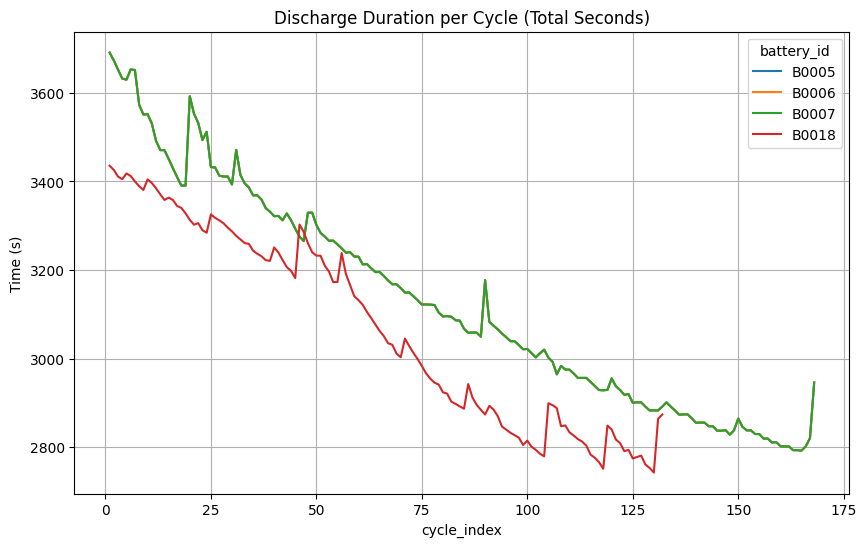

In [39]:
# 사이클별 방전 시간(초) 계산
discharge_duration = df_battery_discharge.groupby(['battery_id', 'cycle_index'])['Time'].max().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=discharge_duration, x='cycle_index', y='Time', hue='battery_id')
plt.title('Discharge Duration per Cycle (Total Seconds)')
plt.ylabel('Time (s)')
plt.grid(True)
plt.show()

In [40]:

# 1. 배터리별/사이클별 시작 및 종료 전압 추출
voltage_analysis = df_battery_discharge.groupby(['battery_id', 'cycle_index'])['Voltage_measured'].agg(['first', 'last']).reset_index()

# 컬럼명 변경 (시작 전압, 종료 전압)
voltage_analysis.columns = ['battery_id', 'cycle_index', 'V_start', 'V_end']

# 2. 전압 차이(Drop) 계산
# 차이가 클수록 해당 시간 동안 에너지를 많이 소모했거나 저항이 커서 전압이 빨리 떨어진 것임
voltage_analysis['V_drop'] = voltage_analysis['V_start'] - voltage_analysis['V_end']

# 3. 배터리별 평균 전압 하락폭 통계 확인
print("📊 [배터리별 전압 분석 요약]")
summary = voltage_analysis.groupby('battery_id')[['V_start', 'V_end', 'V_drop']].min()
print(summary)

# 4. 특정 사이클(예: 1번 사이클) 결과만 상세 보기
print("\n🔍 [1번 사이클 상세 비교]")
print(voltage_analysis[voltage_analysis['cycle_index'] == 1])

📊 [배터리별 전압 분석 요약]
             V_start     V_end    V_drop
battery_id                              
B0005       4.184535  3.205069  0.574433
B0006       4.157545  2.120698  0.464486
B0007       4.188843  1.813269  0.769522
B0018       4.181407  3.053230  0.681246

🔍 [1번 사이클 상세 비교]
    battery_id  cycle_index   V_start     V_end    V_drop
0        B0005            1  4.191492  3.277170  0.914322
168      B0006            1  4.179800  2.475768  1.704032
336      B0007            1  4.199360  3.062113  1.137247
504      B0018            1  4.188109  3.053230  1.134878


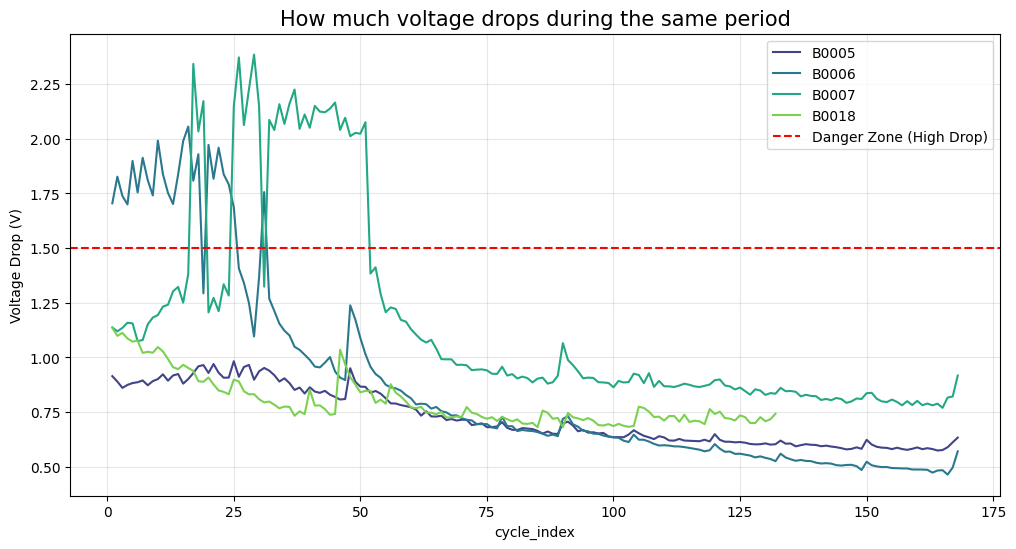

In [41]:
plt.figure(figsize=(12, 6))
# 사이클이 진행될수록 V_drop이 커지는지(즉, 전압이 더 빨리 떨어지는지) 확인
sns.lineplot(data=voltage_analysis, x='cycle_index', y='V_drop', hue='battery_id', palette='viridis')

plt.title('How much voltage drops during the same period', fontsize=15)
plt.axhline(y=1.5, color='r', linestyle='--', label='Danger Zone (High Drop)') # 임의의 기준선
plt.ylabel('Voltage Drop (V)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [42]:
# 동일한 사이클(예: 50번 사이클)에서 종료 직전 전압 비교
target_cycle = 50 

print(f"📊 [사이클 {target_cycle}] 종료 직전(3690초 부근) 전압 비교")
for b_id in ['B0005', 'B0006', 'B0007', 'B0018']:
    # 해당 배터리/사이클의 마지막 행 가져오기
    last_row = df_battery_discharge[(df_battery_discharge['battery_id'] == b_id) & 
                                     (df_battery_discharge['cycle_index'] == target_cycle)].iloc[-1:]
    
    if not last_row.empty:
        v_end = last_row['Voltage_measured'].values[0]
        t_end = last_row['Time'].values[0]
        print(f"{b_id} -> 종료시간: {t_end:.1f}s | 종료전압: {v_end:.4f}V")

📊 [사이클 50] 종료 직전(3690초 부근) 전압 비교
B0005 -> 종료시간: 3301.6s | 종료전압: 3.3329V
B0006 -> 종료시간: 3301.6s | 종료전압: 3.0982V
B0007 -> 종료시간: 3301.6s | 종료전압: 2.1801V
B0018 -> 종료시간: 3232.3s | 종료전압: 3.3472V


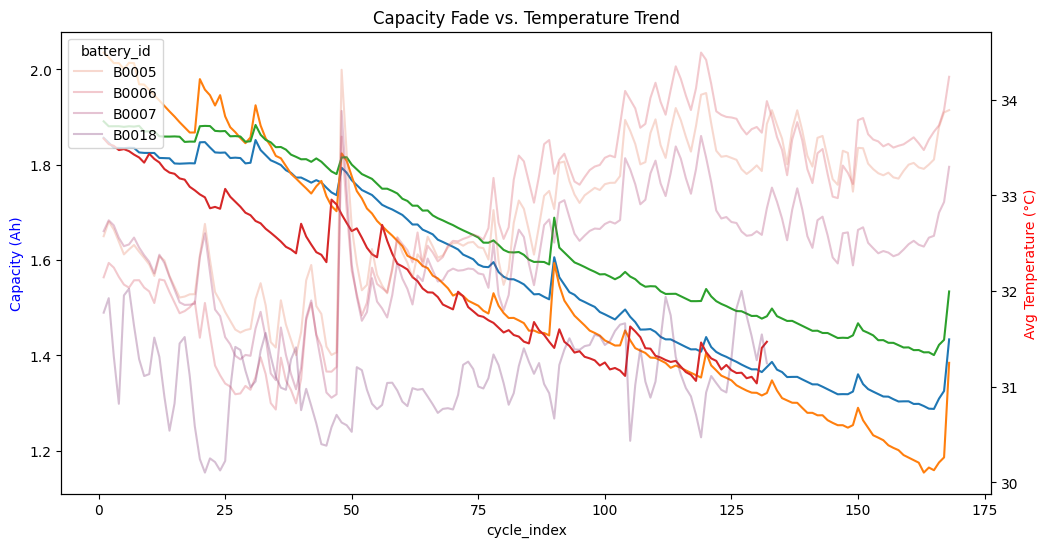

In [43]:
# 2. 온도변화와 용량의 상관관계

# 1. 사이클별 평균 온도 추출
temp_summary = df_battery_discharge.groupby(['battery_id', 'cycle_index'])['Temperature_measured'].mean().reset_index()

# 2. 기존 비교 데이터프레임과 합치기
analysis_df = pd.merge(final_comparison_df, temp_summary, on=['battery_id', 'cycle_index'])

# 3. 시각화 (용량 감소와 온도 상승의 관계)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 용량 그래프 (왼쪽 축)
sns.lineplot(data=analysis_df, x='cycle_index', y='Provided_Capacity', hue='battery_id', ax=ax1, legend=False)
ax1.set_ylabel('Capacity (Ah)', color='blue')

# 온도 그래프 (오른쪽 축)
ax2 = ax1.twinx()
sns.lineplot(data=analysis_df, x='cycle_index', y='Temperature_measured', hue='battery_id', ax=ax2, palette='flare', alpha=0.3)
ax2.set_ylabel('Avg Temperature (°C)', color='red')

plt.title('Capacity Fade vs. Temperature Trend')
plt.show()

C:\Users\skrke\AppData\Local\Temp\ipykernel_14680\2918471150.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_df = df_battery_discharge.groupby(['battery_id', 'cycle_index']).apply(precompute_discharge_time).reset_index()


시각화 완료.


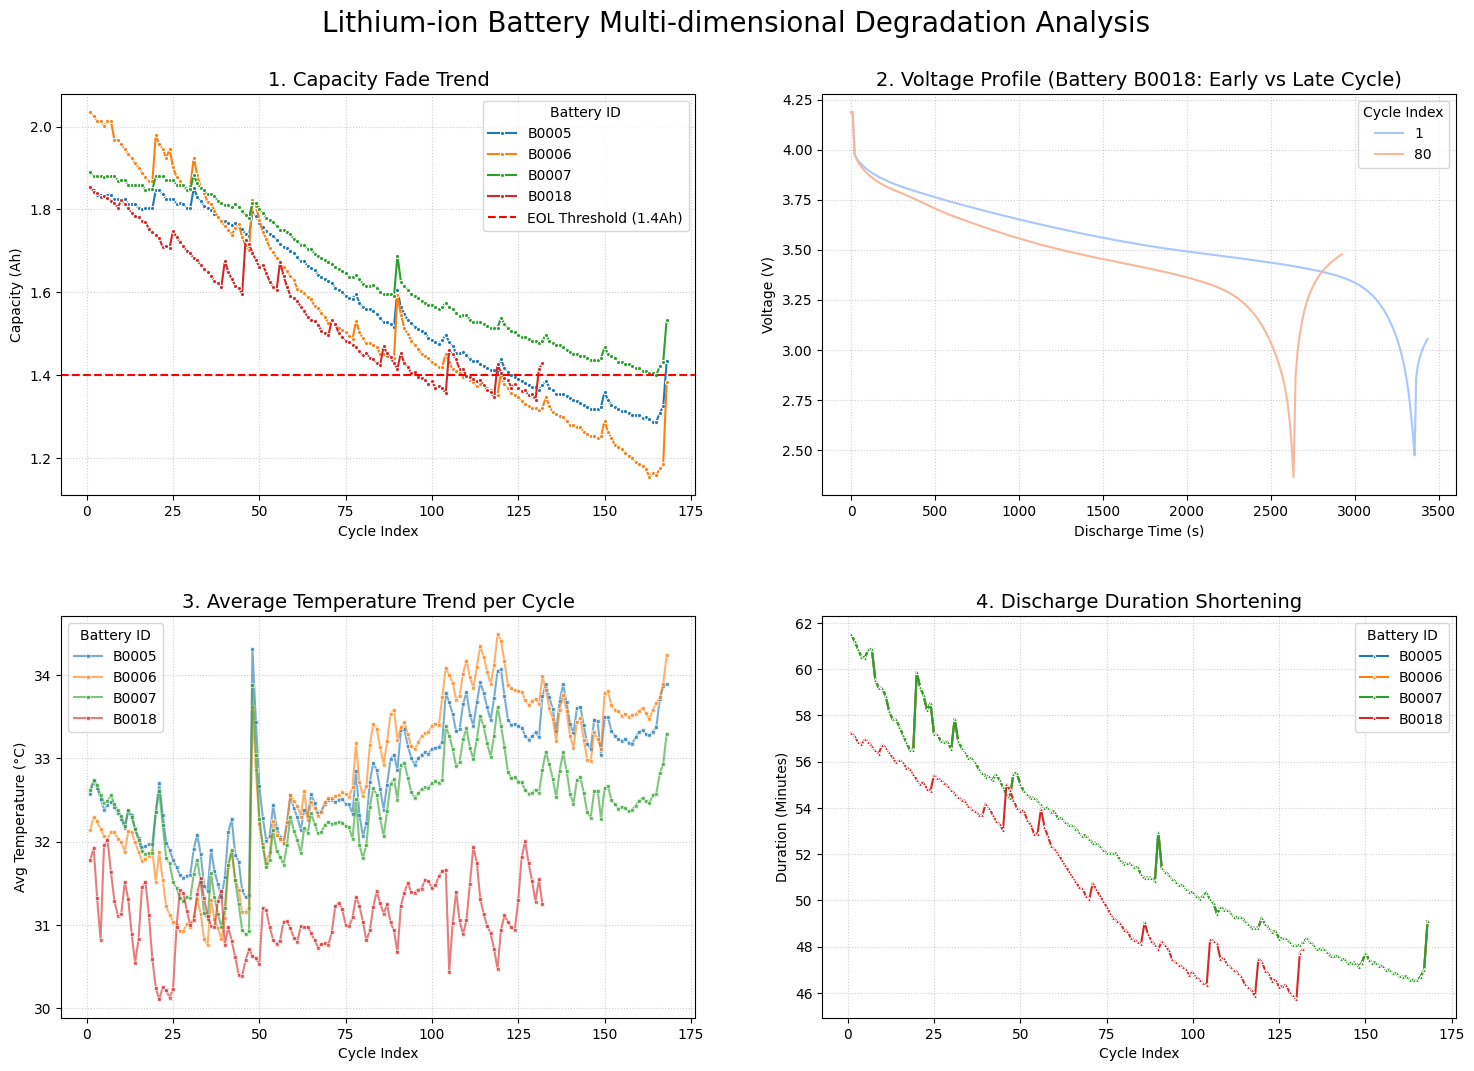

In [44]:
# cycle별 다양한 시각화

# 데이터가 많으므로 방전 시간 전처리를 위해 그룹화
def precompute_discharge_time(group):
    # 방전 지속 시간 (분 단위)
    discharge_time_min = (group['Time'].max() - group['Time'].min()) / 60
    # 평균 온도
    avg_temp = group['Temperature_measured'].mean()
    # 요약 데이터 반환
    return pd.Series({
        'Discharge_Time_Min': discharge_time_min,
        'Avg_Temperature': avg_temp,
        # 용량은 사이클당 하나이므로 첫 값 사용
        'Capacity': group['Capacity'].iloc[0]
    })

# 전처리 실행 (배터리별, 사이클별)
summary_df = df_battery_discharge.groupby(['battery_id', 'cycle_index']).apply(precompute_discharge_time).reset_index()

# 시각화 설정
fig, axes = plt.subplots(2, 2, figsize=(18, 12), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})
plt.suptitle('Lithium-ion Battery Multi-dimensional Degradation Analysis', fontsize=20, y=0.95)

# --- [1. 용량 감소 추세 (Capacity Fade)] ---
ax1 = axes[0, 0]
sns.lineplot(data=summary_df, x='cycle_index', y='Capacity', hue='battery_id', marker='o', markersize=3, ax=ax1)
ax1.axhline(y=1.4, color='red', linestyle='--', label='EOL Threshold (1.4Ah)')
ax1.set_title('1. Capacity Fade Trend', fontsize=14)
ax1.set_ylabel('Capacity (Ah)')
ax1.set_xlabel('Cycle Index')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title='Battery ID')

# --- [2. 전압 강하 패턴 비교 (Voltage Profile)] ---
ax2 = axes[0, 1]
# 비교를 위해 특정 배터리(예: B0005)의 초기와 말기 사이클 추출
target_b_id = 'B0018'
cycles_to_compare = [1, 80] # 데이터에 존재하는 사이클 번호로 조정 필요

# 전체 통합 데이터에서 원본 시계열 추출
v_profile_df = df_battery_discharge[
    (df_battery_discharge['battery_id'] == target_b_id) & 
    (df_battery_discharge['cycle_index'].isin(cycles_to_compare))
].copy()

# 시각화를 위해 사이클 이름을 문자열로 변경
v_profile_df['Cycle'] = v_profile_df['cycle_index'].astype(str)

sns.lineplot(data=v_profile_df, x='Time', y='Voltage_measured', hue='Cycle', palette='coolwarm', ax=ax2)
ax2.set_title(f'2. Voltage Profile (Battery {target_b_id}: Early vs Late Cycle)', fontsize=14)
ax2.set_ylabel('Voltage (V)')
ax2.set_xlabel('Discharge Time (s)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(title='Cycle Index')

# --- [3. 평균 온도 변화 (Avg Temperature)] ---
ax3 = axes[1, 0]
sns.lineplot(data=summary_df, x='cycle_index', y='Avg_Temperature', hue='battery_id', marker='s', markersize=3, alpha=0.6, ax=ax3)
ax3.set_title('3. Average Temperature Trend per Cycle', fontsize=14)
ax3.set_ylabel('Avg Temperature (°C)')
ax3.set_xlabel('Cycle Index')
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(title='Battery ID', loc='upper left')

# --- [4. 방전 지속 시간 단축 (Discharge Time)] ---
ax4 = axes[1, 1]
sns.lineplot(data=summary_df, x='cycle_index', y='Discharge_Time_Min', hue='battery_id', marker='^', markersize=3, ax=ax4)
ax4.set_title('4. Discharge Duration Shortening', fontsize=14)
ax4.set_ylabel('Duration (Minutes)')
ax4.set_xlabel('Cycle Index')
ax4.grid(True, linestyle=':', alpha=0.6)
ax4.legend(title='Battery ID')

print("시각화 완료.")
plt.show()

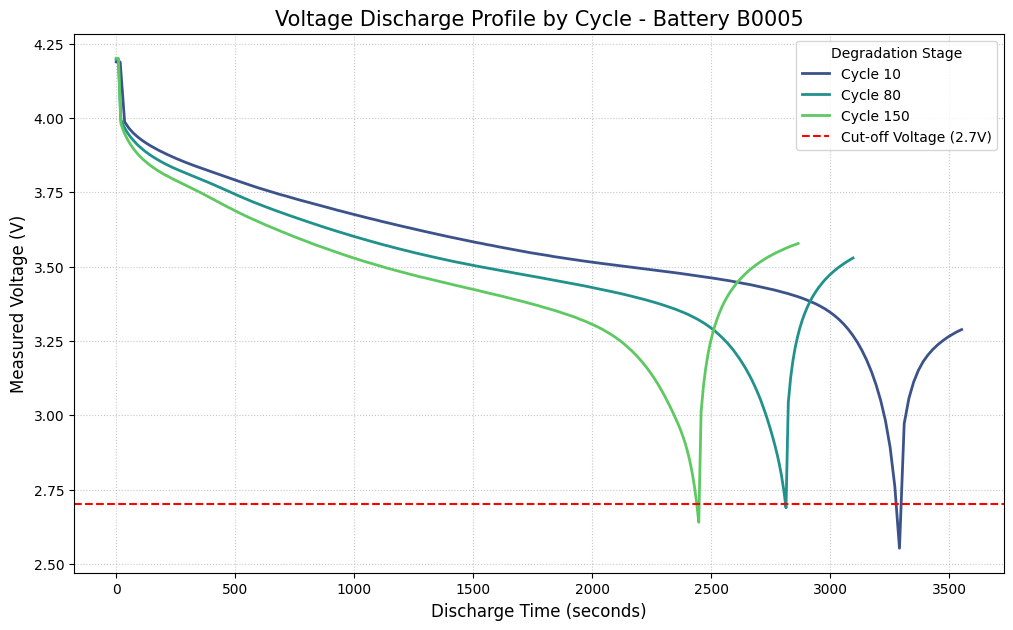

In [45]:


# 1. 분석할 배터리 선택 및 비교할 사이클 설정
target_b_id = 'B0005'
# 초기(10), 중기(80), 말기(150) 사이클을 선택하여 비교
comparison_cycles = [10, 80, 150] 

# 2. 데이터 필터링
# 통합 데이터프레임에서 해당 배터리와 선택한 사이클만 추출
v_trend_df = df_battery_discharge[
    (df_battery_discharge['battery_id'] == target_b_id) & 
    (df_battery_discharge['cycle_index'].isin(comparison_cycles))
].copy()

# 시각화를 위해 사이클 번호를 문자열(범주형)로 변환
v_trend_df['Cycle'] = v_trend_df['cycle_index'].apply(lambda x: f"Cycle {x}")

# 3. 시각화
plt.figure(figsize=(12, 7))

# 시간(Time)에 따른 전압(Voltage_measured) 변화
sns.lineplot(data=v_trend_df, x='Time', y='Voltage_measured', hue='Cycle', palette='viridis', linewidth=2)

# 방전 종지 전압(Cut-off Voltage) 표시 (보통 2.7V ~ 3.0V 사이)
plt.axhline(y=2.7, color='red', linestyle='--', label='Cut-off Voltage (2.7V)')

plt.title(f'Voltage Discharge Profile by Cycle - Battery {target_b_id}', fontsize=15)
plt.xlabel('Discharge Time (seconds)', fontsize=12)
plt.ylabel('Measured Voltage (V)', fontsize=12)
plt.legend(title="Degradation Stage")
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [ ]:
df_battery_discharge.columns

In [46]:
# soh

# 1. 배터리 ID와 사이클 번호로 정렬 (시간 순서 보장)
df_battery_discharge = df_battery_discharge.sort_values(by=['battery_id', 'cycle_index'])

# 2. 각 배터리(battery_id) 그룹별로 '맨 처음(첫 행)'의 Capacity를 찾아 새로운 컬럼으로 생성
# transform('first')를 쓰면 그룹 내 첫 번째 값이 모든 사이클 행에 분모로 들어갑니다.
df_battery_discharge['initial_capacity'] = df_battery_discharge.groupby('battery_id')['Capacity'].transform('first')

# 3. SOH 계산: (현재 사이클의 capacity / 해당 배터리의 초기 capacity) * 100
df_battery_discharge['SOH'] = (df_battery_discharge['Capacity'] / df_battery_discharge['initial_capacity']) * 100

# 4. 결과 확인 (배터리 ID, 사이클, 현재용량, 초기용량, SOH 순서)
print(df_battery_discharge[['battery_id', 'cycle_index', 'Capacity', 'initial_capacity', 'SOH']])

       battery_id  cycle_index  Capacity  initial_capacity         SOH
0           B0005            1  1.856487          1.856487  100.000000
1           B0005            1  1.856487          1.856487  100.000000
2           B0005            1  1.856487          1.856487  100.000000
3           B0005            1  1.856487          1.856487  100.000000
4           B0005            1  1.856487          1.856487  100.000000
...           ...          ...       ...               ...         ...
185716      B0018          132  1.428368          1.855005   77.000793
185717      B0018          132  1.428368          1.855005   77.000793
185718      B0018          132  1.428368          1.855005   77.000793
185719      B0018          132  1.428368          1.855005   77.000793
185720      B0018          132  1.428368          1.855005   77.000793

[185721 rows x 5 columns]


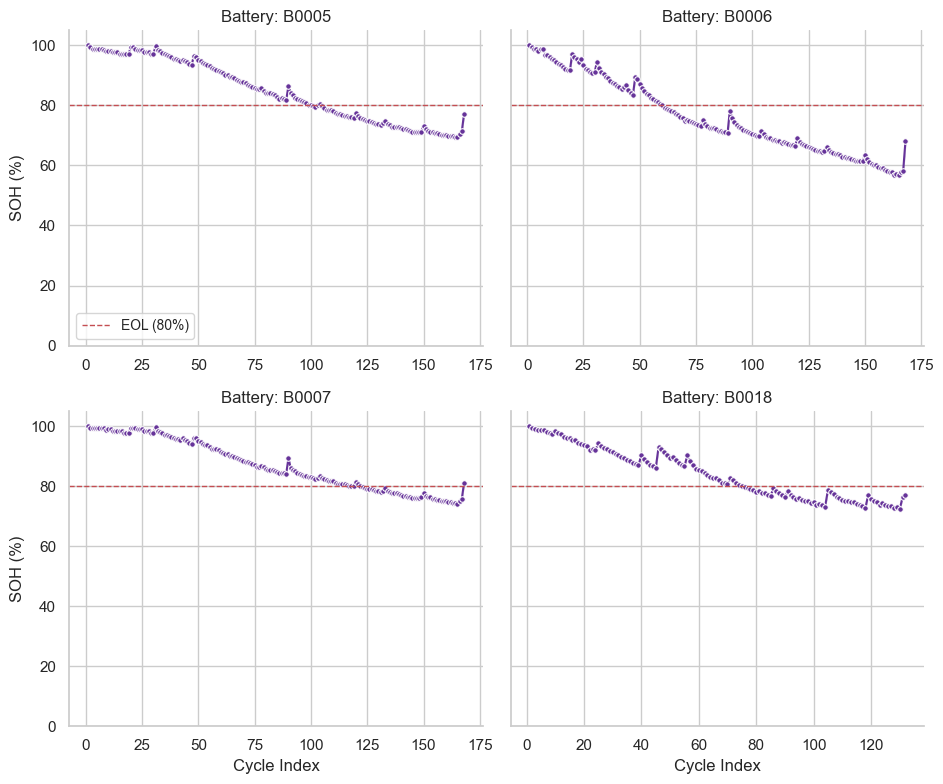

In [47]:
# 1. 시각화 스타일 설정 (Seaborn 기본 테마)
sns.set_theme(style="whitegrid")

# 2. FacetGrid 생성: battery_id 컬럼을 기준으로 격자(Grid) 나누기
# col="battery_id": 배터리 ID별로 가로로 나열 (칸)
# col_wrap=2: 한 줄에 최대 2개씩 배치 (배터리가 많을 때 유용)
# sharex=False, sharey=True: X축(사이클) 범위는 달라도 되지만, Y축(SOH) 범위는 통일
g = sns.FacetGrid(df_battery_discharge, col="battery_id", col_wrap=2, 
                  height=4, aspect=1.2, sharex=False, sharey=True)

# 3. 각 격자에 실제 그래프 그리기 (꺾은선 그래프 + 산점도)
# sns.lineplot: 꺾은선
# "cycle_index": X축
# "SOH": Y축
g.map(sns.lineplot, "cycle_index", "SOH", marker="o", color="rebeccapurple", linewidth=1.5, markersize=4)

# 4. 그래프 디테일 설정
# 각 서브플롯의 제목 형식 설정 (예: Battery: B0005)
g.set_titles(template="Battery: {col_name}")

# X축, Y축 라벨 설정
g.set_axis_labels("Cycle Index", "SOH (%)")

# Y축 범위 고정 (SOH는 0~100% 사이이므로)
# 데이터에 따라 100%를 약간 넘을 수 있다면 범위를 조절하세요 (예: 0, 110)
g.set(ylim=(0, 105)) 

# 5. 수명 종료(EOL) 기준선 추가 (옵션: SOH 80%)
# 각 서브플롯을 순회하며 빨간 점선 추가
for ax in g.axes.flat:
    ax.axhline(y=80, color='r', linestyle='--', linewidth=1, label='EOL (80%)')
    # 첫 번째 그래프에만 범례 표시 (깔끔하게)
    if ax == g.axes.flat[0]:
        ax.legend(loc='lower left', fontsize='small')

# 6. 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

# 임피던스 분석





In [48]:
# 임피던스 배터리 모두 통합 (df_battery_impedance)

target_ids = ['B0005', 'B0006', 'B0007', 'B0018']
master_list = []

for b_id in target_ids:
    # 1. 기존 방전 요약 데이터에서 해당 배터리 추출
    dis_data = final_comparison_df[final_comparison_df['battery_id'] == b_id].copy()
    
    # 2. 이미 존재하는 임피던스 변수 가져오기 (globals 활용)
    imp_df_name = f"df_impedance_{b_id}"
    if imp_df_name in globals():
        imp_data = globals()[imp_df_name].copy()
        
        # 3. 데이터 결합 (Cycle_index 기준)
        # 모든 컬럼(Sense_current, Rectified_Impedance, Re, Rct 등)을 가져옵니다.
        merged = pd.merge(
            dis_data, 
            imp_data, 
            on=['cycle_index', 'battery_id'], 
            how='outer' # 양쪽 데이터가 모두 보존되도록 outer join
        )
        master_list.append(merged)

# 4. 전체 배터리 통합 마스터 데이터프레임 생성
df_battery_impedance = pd.concat(master_list, ignore_index=True)

# 5. 시계열 순서로 정렬
df_battery_impedance = df_battery_impedance.sort_values(['battery_id', 'cycle_index'])

# 결과 확인
print("✅ 마스터 데이터 통합 완료!")
display(df_battery_impedance)

✅ 마스터 데이터 통합 완료!


,battery_id,cycle_index,Integrated_Ah,Provided_Capacity,Error_Rate(%),Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,filename,type,start_time,ambient_temperature,Re,Rct
0,B0005,1,1.861952,1.856487,0.294348,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j),05161.csv,impedance,2008-04-18 20:55:30,24.0,0.044669,0.069456
1,B0005,1,1.861952,1.856487,0.294348,(820.6094970703125-36.23455047607422j),(337.0914611816406-82.9207763671875j),(2.3204145178633437+0.4633045948164565j),(0.13008840651776496-0.19711481029612374j),(0.06817886114940203-0.001190040925296937j),05161.csv,impedance,2008-04-18 20:55:30,24.0,0.044669,0.069456
2,B0005,1,1.861952,1.856487,0.294348,(827.2421875-48.23122787475586j),(330.6315612792969-70.01371765136719j),(2.424192647592199+0.36746495469515333j),(0.058770560504133235+0.03330656583655633j),(0.06793257733714593-5.6826811936507056e-05j),05161.csv,impedance,2008-04-18 20:55:30,24.0,0.044669,0.069456
3,B0005,1,1.861952,1.856487,0.294348,(827.1934814453125-56.195716857910156j),(330.8086242675781-61.73442459106445j),(2.4470021712116985+0.28677775364826635j),(0.0058135116366746726-0.060546548141956195j),(0.06691839226387165-0.0008787264015490232j),05161.csv,impedance,2008-04-18 20:55:30,24.0,0.044669,0.069456
4,B0005,1,1.861952,1.856487,0.294348,(824.9295043945312-53.241477966308594j),(332.68267822265625-57.62901306152344j),(2.434304977711638+0.2616460702282485j),(0.12608106668700975-0.09044390544679616j),(0.06807105294348659-0.0001974802021297548j),05161.csv,impedance,2008-04-18 20:55:30,24.0,0.044669,0.069456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42650,B0018,128,1.363689,1.351865,0.874664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
42651,B0018,129,1.374382,1.354797,1.445642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
42652,B0018,130,1.360682,1.341051,1.463803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
42653,B0018,131,1.433741,1.415561,1.284350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


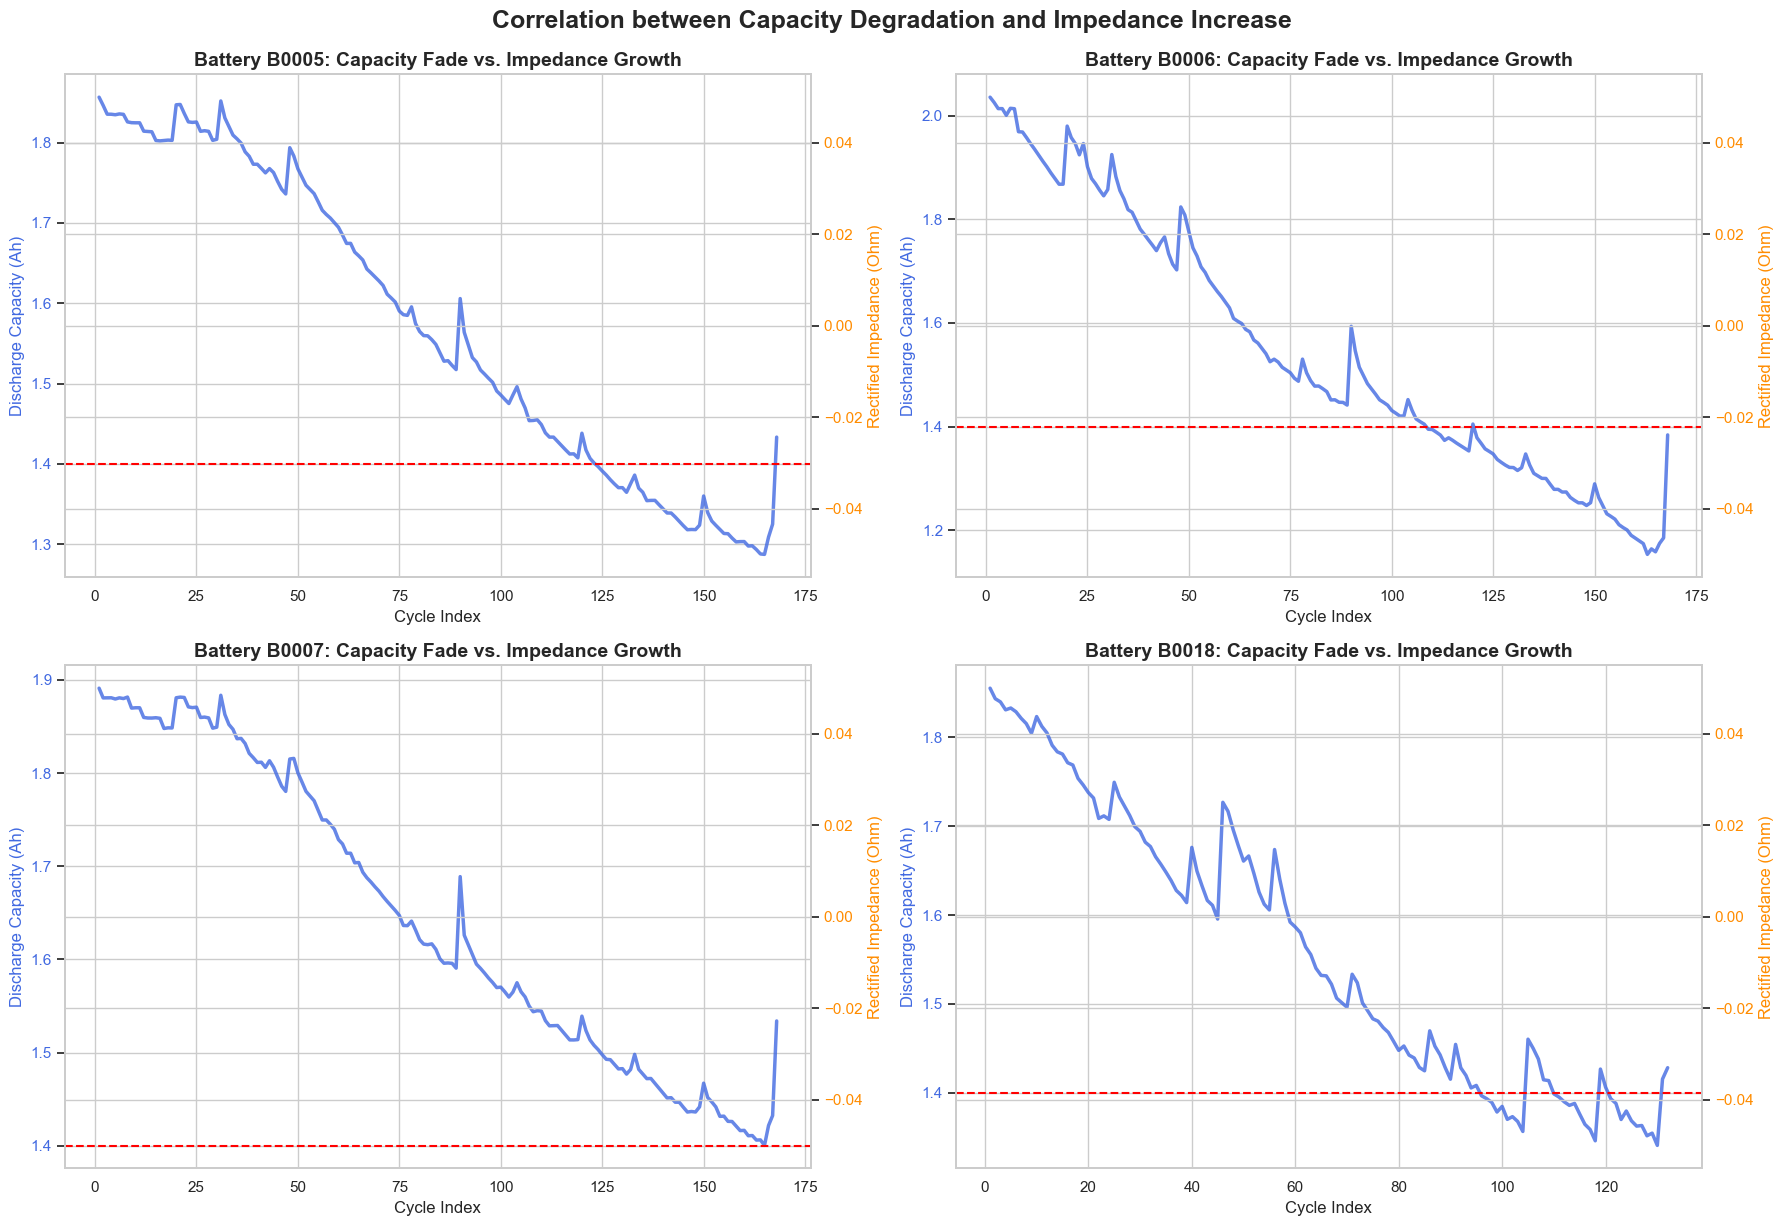

In [49]:
# 핵심 시각화 1: 용량 vs 보정된 임피던스 (X자형 교차 그래프)

# [추가] 데이터 타입 클리닝: Rectified_Impedance가 float인지 확인하고 강제 변환
# 만약 리스트나 문자열로 되어 있다면 첫 번째 요소만 추출하거나 숫자로 바꿉니다.
def clean_impedance_value(val):
    try:
        if isinstance(val, (list, np.ndarray)):
            return float(val[0]) # 리스트면 첫 번째 값 추출
        return float(val) # 숫자형태면 그대로 float 변환
    except:
        return np.nan # 변환 실패 시 NaN 처리

# 클리닝 적용
df_battery_impedance['Rectified_Impedance'] = df_battery_impedance['Rectified_Impedance'].apply(clean_impedance_value)
df_battery_impedance['Provided_Capacity'] = pd.to_numeric(df_battery_impedance['Provided_Capacity'], errors='coerce')

# 1. 시각화 스타일 및 한글 폰트 설정 (필요시)
plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")

# 2. 배터리별로 서브플롯 생성 (2x2 형태)
target_ids = ['B0005', 'B0006', 'B0007', 'B0018']
for i, b_id in enumerate(target_ids, 1):
    ax1 = plt.subplot(2, 2, i)
    
    # 해당 배터리 데이터만 필터링 및 정렬
    target_df = df_battery_impedance[df_battery_impedance['battery_id'] == b_id].sort_values('cycle_index')
    
    # --- 왼쪽 Y축: 방전 용량 (Capacity) ---
    color_cap = 'royalblue'
    ax1.set_xlabel('Cycle Index', fontsize=12)
    ax1.set_ylabel('Discharge Capacity (Ah)', color=color_cap, fontsize=12)
    lns1 = ax1.plot(target_df['cycle_index'], target_df['Provided_Capacity'], 
                    label='Capacity (Ah)', color=color_cap, linewidth=2.5, alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color_cap)
    
    # 수명 종료(EOL) 기준선 추가 (1.4Ah)
    ax1.axhline(y=1.4, color='red', linestyle='--', linewidth=1.5, label='EOL (1.4Ah)')

    # --- 오른쪽 Y축 (이중 축): 보정된 임피던스 (Rectified_Impedance) ---
    ax2 = ax1.twinx()  # 이중 축 설정
    color_imp = 'darkorange'
    ax2.set_ylabel('Rectified Impedance (Ohm)', color=color_imp, fontsize=12)
    # 임피던스는 모든 사이클에 데이터가 없으므로 점(Scatter)으로 표현하는 것이 좋습니다.
    lns2 = ax2.scatter(target_df['cycle_index'], target_df['Rectified_Impedance'], 
                       label='Rectified Impedance', color=color_imp, s=15, alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color_imp)

    # 타이틀 설정
    plt.title(f'Battery {b_id}: Capacity Fade vs. Impedance Growth', fontsize=14, fontweight='bold')
    
    # 범례 합치기
    lns = lns1 + [lns2]
    labs = [l.get_label() for l in lns]
    # ax1.legend(lns, labs, loc='center right') # 범례 위치 조정 필요시

# 3. 전체 레이아웃 조정 및 출력
plt.tight_layout()
plt.suptitle('Correlation between Capacity Degradation and Impedance Increase', fontsize=18, y=1.02, fontweight='bold')
plt.show()

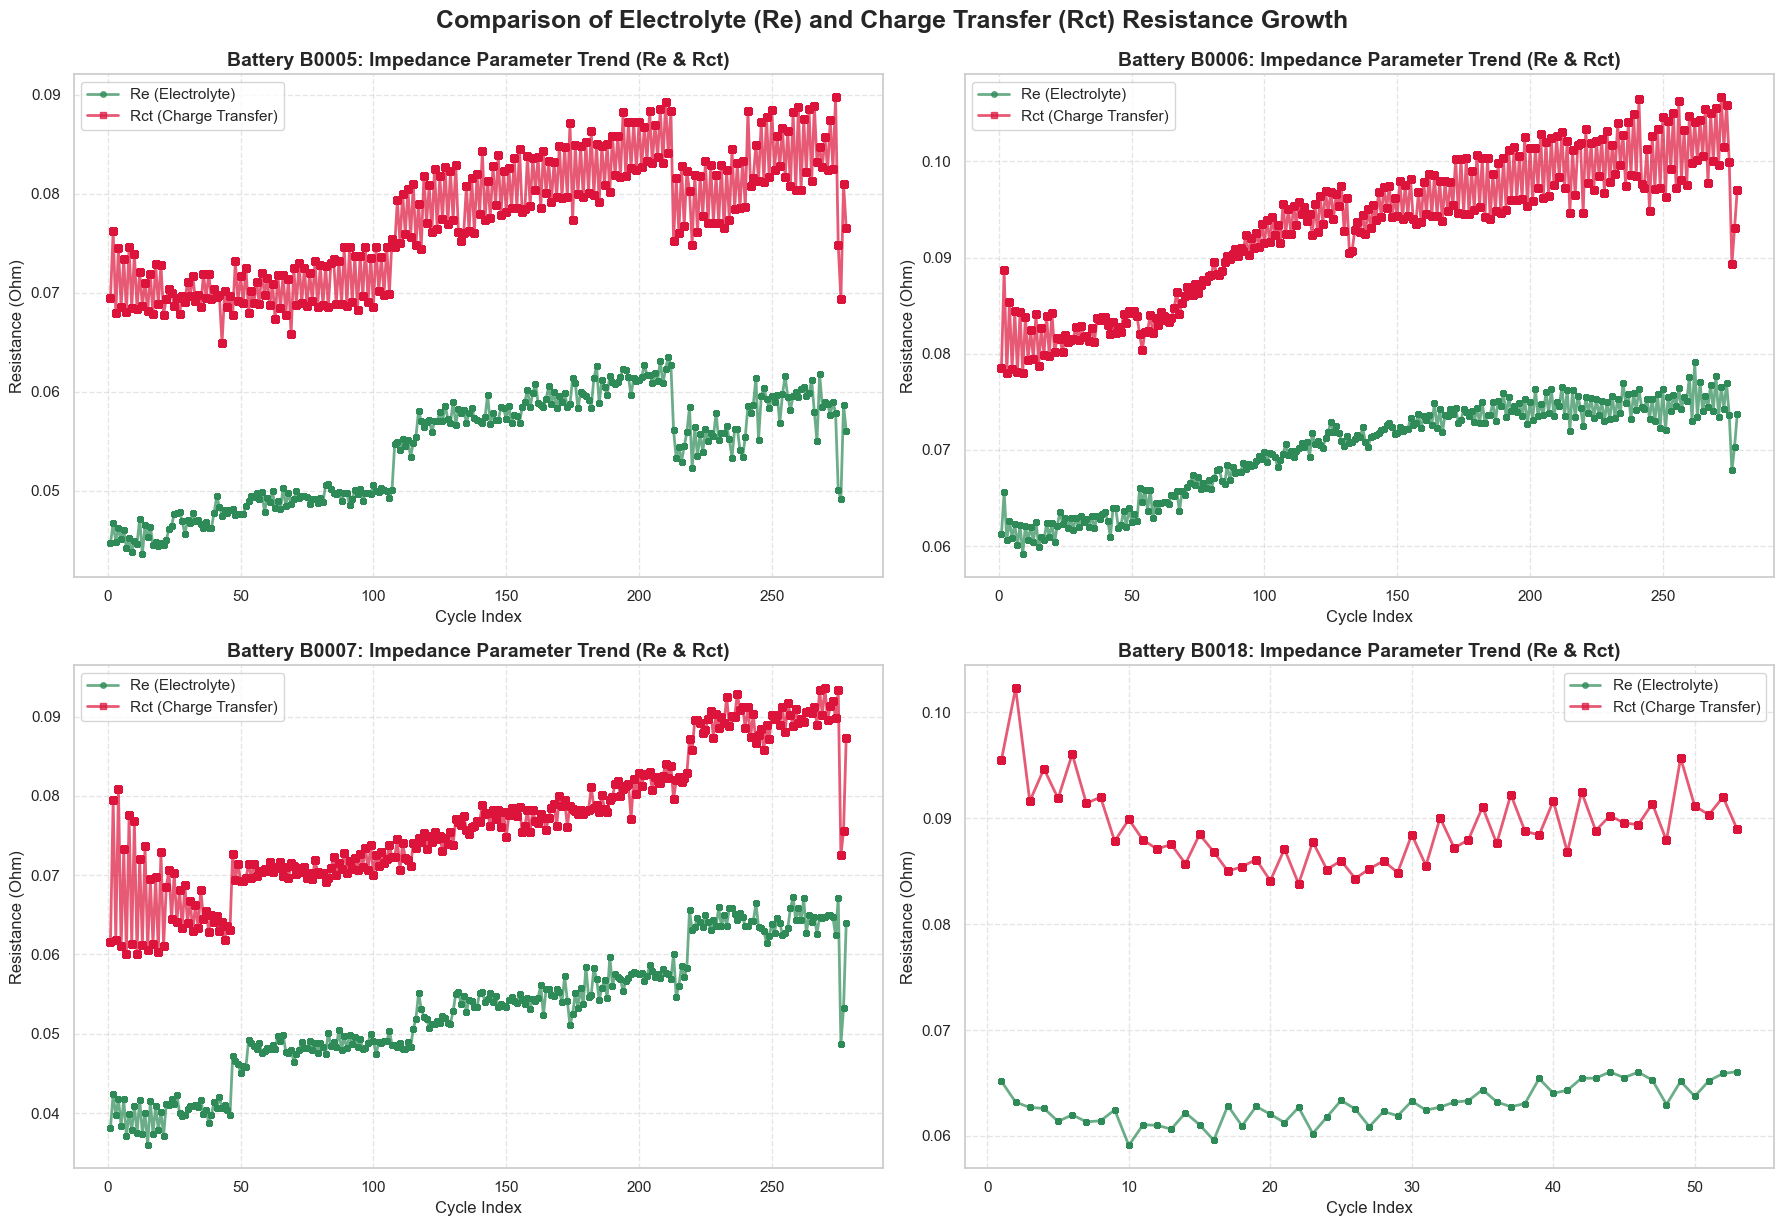

In [50]:
# 핵심 시각화 2: 전해질 저항(Re) vs 전하 전달 저항(Rct) 흐름 비교

plt.figure(figsize=(18, 12))

for i, b_id in enumerate(target_ids, 1):
    plt.subplot(2, 2, i)
    
    target_df = df_battery_impedance[df_battery_impedance['battery_id'] == b_id].sort_values('cycle_index')
    
    # Re (Electrolyte Resistance) - 전해질 저항
    plt.plot(target_df['cycle_index'], target_df['Re'], 
             label='Re (Electrolyte)', color='seagreen', linewidth=2, marker='o', markersize=4, alpha=0.7)
    
    # Rct (Charge Transfer Resistance) - 전하 전달 저항
    plt.plot(target_df['cycle_index'], target_df['Rct'], 
             label='Rct (Charge Transfer)', color='crimson', linewidth=2, marker='s', markersize=4, alpha=0.7)
    
    plt.title(f'Battery {b_id}: Impedance Parameter Trend (Re & Rct)', fontsize=14, fontweight='bold')
    plt.xlabel('Cycle Index')
    plt.ylabel('Resistance (Ohm)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('Comparison of Electrolyte (Re) and Charge Transfer (Rct) Resistance Growth', fontsize=18, y=1.02, fontweight='bold')
plt.show()

# 충전 분석